# Late Fusion: Wav2Vec2 + DistilBERT

This notebook evaluates late fusion of Wav2Vec2 (audio transformer) with DistilBERT (text transformer) for 3-language identification (English, Malay, Chinese).

**Models:**
- Audio: Wav2Vec2 trained on 7.5h audio → `best_wav2vec2_model_7p5h/`
- Text: DistilBERT trained on 5000 OCR images/language → `distilbert_grid_best.pth`

**Fusion Strategies:**
1. Equal weighting (0.5/0.5)
2. Accuracy-based weighting (0.6 audio / 0.4 text)
3. Confidence-adaptive weighting

In [9]:
# Imports
import os
import json
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from transformers import Wav2Vec2Processor, Wav2Vec2ForSequenceClassification
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from tqdm.notebook import tqdm

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA GeForce GTX 1650


In [10]:
import warnings
from transformers import logging as hf_logging

# Set transformers to error level (suppresses info/warnings)
hf_logging.set_verbosity_error()

# Suppress specific deprecation warnings
warnings.filterwarnings('ignore', category=UserWarning, message='.*gradient_checkpointing.*')
warnings.filterwarnings('ignore', message='.*Some weights of.*were not initialized.*')

In [11]:
# Configuration
AUDIO_DIR = os.path.join(os.getcwd(), 'Dataset', 'audio_active')
OCR_BASE_DIR = os.path.join(os.getcwd(), 'ocr_images_noisy')

SAMPLE_RATE = 16000
SEGMENT_LENGTH = 10  # 10s segments for better audio-text pairing

LANGUAGES = ['en', 'ms', 'zh']
LANGUAGE_IDS = {'en': 0, 'ms': 1, 'zh': 2}
LANGUAGE_NAMES = ['English', 'Malay', 'Mandarin']

# Model paths
AUDIO_MODEL_PATH = 'best_wav2vec2_model_7p5h'  # Wav2Vec2 checkpoint folder
TEXT_MODEL_PATH = 'distilbert_grid_best.pth'  # DistilBERT state dict
TEXT_MODEL_NAME = 'distilbert-base-multilingual-cased'

# Data split ratios (matching training)
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

print(f'Audio dir: {AUDIO_DIR}')
print(f'OCR dir: {OCR_BASE_DIR}')
print(f'Audio model: {AUDIO_MODEL_PATH}')
print(f'Text model: {TEXT_MODEL_PATH}')

Audio dir: c:\Users\Aaron Lim\Dropbox\PC\Documents\1School\FYP\Dataset\audio_active
OCR dir: c:\Users\Aaron Lim\Dropbox\PC\Documents\1School\FYP\ocr_images_noisy
Audio model: best_wav2vec2_model_7p5h
Text model: distilbert_grid_best.pth


In [12]:
# Load 7.5h audio files and create temporal test split
print('Loading 7.5-hour audio files for test set...')
SEGMENT_LENGTH = 10  # 10s segments for better audio-text pairing
test_audio_segments = []
test_audio_labels = []

for lang_code in LANGUAGES:
    audio_file = os.path.join(AUDIO_DIR, f'{lang_code}_7.5h.wav')
    if not os.path.exists(audio_file):
        print(f'Warning: missing {audio_file}')
        continue
    
    print(f'  Loading {lang_code}_7.5h.wav...')
    waveform, sr = librosa.load(audio_file, sr=SAMPLE_RATE)
    
    # Calculate test split position (last 15%)
    total_len = len(waveform)
    test_start = int(total_len * (TRAIN_RATIO + VAL_RATIO))
    test_waveform = waveform[test_start:]
    
    # Segment into 10s clips
    seg_samples = SEGMENT_LENGTH * SAMPLE_RATE
    num_segments = len(test_waveform) // seg_samples
    
    for i in range(num_segments):
        start = i * seg_samples
        end = start + seg_samples
        segment = test_waveform[start:end]
        test_audio_segments.append(segment)
        test_audio_labels.append(LANGUAGE_IDS[lang_code])
    
    print(f'    {lang_code}: {num_segments} test segments ({len(test_waveform)/SAMPLE_RATE/60:.1f} min)')

print(f'\nTotal audio test samples: {len(test_audio_segments)}')

Loading 7.5-hour audio files for test set...
  Loading en_7.5h.wav...
    en: 405 test segments (67.5 min)
  Loading ms_7.5h.wav...
    ms: 405 test segments (67.5 min)
  Loading zh_7.5h.wav...
    zh: 405 test segments (67.5 min)

Total audio test samples: 1215


In [9]:
# Load OCR images and extract text using TrOCR for test set
import csv
import re
from PIL import Image
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

folder_map = {'en': 'EN', 'ms': 'MY', 'zh': 'CN'}

def clean_text(text):
    if not isinstance(text, str):
        text = str(text)
    text = re.sub(r'[\r\n\t]+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

# Load TrOCR for text extraction from images
print('Loading TrOCR model for image text extraction...')
trocr_processor = TrOCRProcessor.from_pretrained('microsoft/trocr-base-printed')
trocr_model = VisionEncoderDecoderModel.from_pretrained('microsoft/trocr-base-printed').to(device)
trocr_model.eval()
print('✅ TrOCR model loaded\n')

# Extract text from OCR images using TrOCR
text_samples_full = {lc: [] for lc in LANGUAGES}
extraction_stats = {lc: {'success': 0, 'failed': 0, 'empty': 0} for lc in LANGUAGES}

print('Extracting text from OCR images using TrOCR...')
for lang_code in LANGUAGES:
    lang_dir = os.path.join(OCR_BASE_DIR, folder_map[lang_code])
    labels_file = os.path.join(lang_dir, 'labels_noisy.csv')
    
    if not os.path.exists(labels_file):
        labels_file = os.path.join(lang_dir, 'labels.csv')
    
    if not os.path.exists(labels_file):
        print(f'Warning: {lang_code} OCR labels not found')
        continue
    
    # Load image filenames from CSV
    image_files = []
    with open(labels_file, 'r', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            if 'filename' in row:
                image_files.append(row['filename'])
    
    print(f'  Extracting text from {len(image_files)} {lang_code} images...')
    
    with torch.no_grad():
        for img_file in tqdm(image_files, desc=f'TrOCR {lang_code}', leave=False):
            img_path = os.path.join(lang_dir, img_file)
            
            try:
                # Load image
                if not os.path.exists(img_path):
                    extraction_stats[lang_code]['failed'] += 1
                    continue
                
                image = Image.open(img_path).convert('RGB')
                
                # Extract text with TrOCR
                pixel_values = trocr_processor(image, return_tensors='pt').pixel_values.to(device)
                generated_ids = trocr_model.generate(pixel_values, max_new_tokens=64)
                extracted_text = trocr_processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
                
                # Clean text
                extracted_text = clean_text(extracted_text)
                
                if extracted_text.strip():
                    text_samples_full[lang_code].append(extracted_text)
                    extraction_stats[lang_code]['success'] += 1
                else:
                    extraction_stats[lang_code]['empty'] += 1
            
            except Exception as e:
                extraction_stats[lang_code]['failed'] += 1
    
    print(f'  ✓ {lang_code}: {extraction_stats[lang_code]["success"]} extracted, {extraction_stats[lang_code]["empty"]} empty, {extraction_stats[lang_code]["failed"]} failed')



Loading TrOCR model for image text extraction...
✅ TrOCR model loaded

Extracting text from OCR images using TrOCR...
  Extracting text from 5000 en images...


TrOCR en:   0%|          | 0/5000 [00:00<?, ?it/s]

  ✓ en: 5000 extracted, 0 empty, 0 failed
  Extracting text from 5000 ms images...


TrOCR ms:   0%|          | 0/5000 [00:00<?, ?it/s]

  ✓ ms: 5000 extracted, 0 empty, 0 failed
  Extracting text from 5000 zh images...


TrOCR zh:   0%|          | 0/5000 [00:00<?, ?it/s]

  ✓ zh: 5000 extracted, 0 empty, 0 failed


In [13]:
import csv
import re
from PIL import Image
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

folder_map = {'en': 'EN', 'ms': 'MY', 'zh': 'CN'}

def clean_text(text):
    if not isinstance(text, str):
        text = str(text)
    text = re.sub(r'[\r\n\t]+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

# Load TrOCR for text extraction from images
print('Loading TrOCR model for image text extraction...')
trocr_processor = TrOCRProcessor.from_pretrained('microsoft/trocr-base-printed')
trocr_model = VisionEncoderDecoderModel.from_pretrained('microsoft/trocr-base-printed').to(device)
trocr_model.eval()
print('✅ TrOCR model loaded\n')

Loading TrOCR model for image text extraction...
✅ TrOCR model loaded



In [11]:
# Inspect and export TrOCR-extracted text samples
import pandas as pd
import numpy as np

if 'text_samples_full' not in globals() or 'LANGUAGES' not in globals():
    raise RuntimeError('Run the TrOCR extraction cell first to populate text_samples_full and LANGUAGES.')

rows = []
for lc in LANGUAGES:
    for txt in text_samples_full.get(lc, []):
        rows.append({'language': lc, 'text': txt})

df_trocr = pd.DataFrame(rows)
print(f"Total extracted texts: {len(df_trocr)}")

# Counts per language
lang_counts = df_trocr['language'].value_counts().to_dict()
print('Counts per language:', lang_counts)

# Save full export
out_csv = 'trocr_extracted_text_samples.csv'
df_trocr.to_csv(out_csv, index=False)
print(f"Saved: {out_csv}")

# Show a few examples per language
for lc in LANGUAGES:
    subset = df_trocr[df_trocr['language'] == lc]['text']
    n_show = min(5, len(subset))
    print(f"\nExamples ({lc}) — showing {n_show} of {len(subset)}:")
    for i, t in enumerate(subset.head(n_show), start=1):
        print(f"  [{i}] {t}")

# Random mixed sample for a quick glance
if len(df_trocr) > 0:
    n_rand = min(10, len(df_trocr))
    print(f"\nRandom {n_rand} samples across all languages:")
    for i, row in df_trocr.sample(n_rand, random_state=42).iterrows():
        print(f"  [{row['language']}] {row['text']}")

Total extracted texts: 15000
Counts per language: {'en': 5000, 'ms': 5000, 'zh': 5000}
Saved: trocr_extracted_text_samples.csv

Examples (en) — showing 5 of 5000:
  [1] THIS KIND OF "TRICK QUESTION" IS OFTEN USED IN APTIT
  [2] COSNITIVE EVALUATIONS - COME AGAIN BHD
  [3] BYPERPLYING OPATIONIES, AND FACEPRICELL SDNY PROTIPER
  [4] BYTLES HAPPING THE ORGANDA PUNCH TRAINING DATE
  [5] ROBENETIVILY, THEY USPY,SHOWED THE POTENTRI OFT

Examples (ms) — showing 5 of 5000:
  [1] PATERIABLEAN TELLA 1887, TEND MEATALAKAN KajAN
  [2] KINI SEBARSAI SHAP-X GERAN MEHAURSENBURN V
  [3] GST REGEMBER, MESCLUDYEAHAN PERINDANGER'S
  [4] SALES INI KOPPAN PERINDING ALAH YAWENATAPKEMAN
  [5] BAYKA YEGGERS JALPAYDAHAPHADASUAT AKHORB

Examples (zh) — showing 5 of 5000:
  [1] ***
  [2] ***
  [3] EXCEIPT@6%$5.11
  [4] 387#2X#***
  [5] EXMASTAX($***

Random 10 samples across all languages:
  [zh] ***
  [ms] AKAN MEMPEROLEN DUNIA YANG TERBATAS
  [zh] EE F545004
  [en] GLOBAL LEADER IN ARTIFICIAL INTERLIGENCE BY 2

In [12]:
# Preview: EasyOCR ↔ TrOCR fallback on 5 images per language (non-destructive)
# Includes OCR accuracy evaluation vs ground truth
import os, csv, re, random, torch
from PIL import Image
from tqdm.notebook import tqdm
from difflib import SequenceMatcher
import numpy as np

# Do NOT modify text_samples_full; use local buffers only
preview_rows = []

# EasyOCR setup (install if missing)
try:
    import easyocr
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'easyocr'])
    import easyocr

# Device
gpu_flag = torch.cuda.is_available()

# Ensure TrOCR is available
try:
    trocr_processor
    trocr_model
except NameError:
    from transformers import TrOCRProcessor, VisionEncoderDecoderModel
    trocr_processor = TrOCRProcessor.from_pretrained('microsoft/trocr-base-printed')
    trocr_model = VisionEncoderDecoderModel.from_pretrained('microsoft/trocr-base-printed').to(device)
    trocr_model.eval()

# Readers per language
readers = {
    'en': easyocr.Reader(['en'], gpu=gpu_flag),
    'ms': easyocr.Reader(['ms','en'], gpu=gpu_flag),
    'zh': easyocr.Reader(['ch_sim'], gpu=gpu_flag),
}

def clean_text(text):
    if not isinstance(text, str):
        text = str(text)
    text = re.sub(r'[\r\n\t]+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def read_easyocr(reader, image_path):
    try:
        out = reader.readtext(image_path, detail=0)  # list of strings
        # Join pieces and prefer longest if needed
        if isinstance(out, list) and len(out) > 0:
            joined = ' '.join([s for s in out if isinstance(s, str)])
            return clean_text(joined)
        return ''
    except Exception:
        return ''

def read_trocr(image_path):
    try:
        image = Image.open(image_path).convert('RGB')
        pixel_values = trocr_processor(image, return_tensors='pt').pixel_values.to(device)
        with torch.no_grad():
            generated_ids = trocr_model.generate(pixel_values, max_new_tokens=96, num_beams=5, early_stopping=True)
        text = trocr_processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
        return clean_text(text)
    except Exception:
        return ''

def choose_text(lang_code, easy_txt, trocr_txt):
    # Heuristic: CN prefers EasyOCR if non-empty; EN/MS prefer TrOCR if non-empty
    if lang_code == 'zh':
        if len(easy_txt) >= 5:
            return easy_txt, 'easyocr'
        elif len(trocr_txt) >= 5:
            return trocr_txt, 'trocr'
        else:
            return (easy_txt if len(easy_txt) >= len(trocr_txt) else trocr_txt), ('easyocr' if len(easy_txt) >= len(trocr_txt) else 'trocr')
    else:
        if len(trocr_txt) >= 5:
            return trocr_txt, 'trocr'
        elif len(easy_txt) >= 5:
            return easy_txt, 'easyocr'
        else:
            return (trocr_txt if len(trocr_txt) >= len(easy_txt) else easy_txt), ('trocr' if len(trocr_txt) >= len(easy_txt) else 'easyocr')

print('Previewing 5 images per language with EasyOCR↔TrOCR fallback...')
for lang_code in LANGUAGES:
    # Build image list from labels (noisy dir by current OCR_BASE_DIR)
    folder = folder_map.get(lang_code, lang_code.upper())
    lang_dir = os.path.join(OCR_BASE_DIR, folder)
    labels_file = os.path.join(lang_dir, 'labels_noisy.csv')
    if not os.path.exists(labels_file):
        labels_file = os.path.join(lang_dir, 'labels.csv')
    if not os.path.exists(labels_file):
        print(f'  {lang_code}: labels file missing, skip')
        continue
    image_files = []
    with open(labels_file, 'r', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            if 'filename' in row:
                image_files.append(row['filename'])
    if len(image_files) == 0:
        print(f'  {lang_code}: no filenames in labels, skip')
        continue
    # Sample 5 (deterministic)
    sample_files = image_files[:5]
    print(f'[{lang_code}] Previewing {len(sample_files)} images...')
    r = readers[lang_code]
    for fname in sample_files:
        image_path = os.path.join(lang_dir, fname)
        if not os.path.exists(image_path):
            preview_rows.append({'language': lang_code, 'filename': fname, 'easyocr': '', 'trocr': '', 'chosen': '', 'source': 'missing'})
            print(f'  - {fname}: MISSING')
            continue
        easy_txt = read_easyocr(r, image_path)
        trocr_txt = read_trocr(image_path)
        chosen_txt, source = choose_text(lang_code, easy_txt, trocr_txt)
        preview_rows.append({'language': lang_code, 'filename': fname, 'easyocr': easy_txt, 'trocr': trocr_txt, 'chosen': chosen_txt, 'source': source})
        print(f'  - {fname}:')
        print(f'      easyocr: {easy_txt[:120]}')
        print(f'      trocr  : {trocr_txt[:120]}')
        print(f'      chosen : [{source}] {chosen_txt[:120]}')

import pandas as pd
df_preview = pd.DataFrame(preview_rows)
df_preview.to_csv('ocr_trocr_fallback_preview.csv', index=False)
print('\nSaved preview → ocr_trocr_fallback_preview.csv')
print('Note: This preview does not modify text_samples_full or prior extractions.')

# Evaluate preview accuracy vs ground truth
print('\n' + '='*70)
print('PREVIEW ACCURACY EVALUATION: Fallback Strategy Performance')
print('='*70)

# Install Levenshtein if needed
try:
    from Levenshtein import distance as levenshtein_distance
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'python-Levenshtein'])
    from Levenshtein import distance as levenshtein_distance

def normalize_text(text):
    if not isinstance(text, str):
        text = str(text)
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def character_accuracy(predicted, ground_truth):
    pred = normalize_text(predicted)
    truth = normalize_text(ground_truth)
    
    if len(truth) == 0:
        return 1.0 if len(pred) == 0 else 0.0
    
    matcher = SequenceMatcher(None, pred, truth)
    matching_chars = sum(block.size for block in matcher.get_matching_blocks())
    return matching_chars / len(truth)

# Load ground truth for all languages
ground_truth_all = {}
for lang_code in LANGUAGES:
    folder = folder_map.get(lang_code, lang_code.upper())
    lang_dir = os.path.join(OCR_BASE_DIR, folder)
    labels_file = os.path.join(lang_dir, 'labels_noisy.csv')
    
    if not os.path.exists(labels_file):
        labels_file = os.path.join(lang_dir, 'labels.csv')
    
    if os.path.exists(labels_file):
        with open(labels_file, 'r', encoding='utf-8') as f:
            reader = csv.DictReader(f)
            for row in reader:
                if 'filename' in row and 'text' in row:
                    ground_truth_all[row['filename']] = row['text']

# Evaluate each preview sample
eval_rows = []
for row in preview_rows:
    if row['filename'] not in ground_truth_all or row['source'] == 'missing':
        continue
    
    truth = ground_truth_all[row['filename']]
    chosen = row['chosen']
    easy = row['easyocr']
    trocr = row['trocr']
    
    # Calculate metrics for chosen text
    lev_dist_chosen = levenshtein_distance(normalize_text(chosen), normalize_text(truth))
    char_acc_chosen = character_accuracy(chosen, truth)
    
    # Calculate metrics for individual methods
    lev_dist_easy = levenshtein_distance(normalize_text(easy), normalize_text(truth))
    char_acc_easy = character_accuracy(easy, truth)
    
    lev_dist_trocr = levenshtein_distance(normalize_text(trocr), normalize_text(truth))
    char_acc_trocr = character_accuracy(trocr, truth)
    
    eval_rows.append({
        'filename': row['filename'],
        'language': row['language'],
        'source': row['source'],
        'chosen_lev_dist': lev_dist_chosen,
        'chosen_char_acc': char_acc_chosen,
        'easyocr_lev_dist': lev_dist_easy,
        'easyocr_char_acc': char_acc_easy,
        'trocr_lev_dist': lev_dist_trocr,
        'trocr_char_acc': char_acc_trocr,
    })

if len(eval_rows) > 0:
    eval_df = pd.DataFrame(eval_rows)
    
    # Per-language stats
    for lang_code in LANGUAGES:
        lang_df = eval_df[eval_df['language'] == lang_code]
        if len(lang_df) > 0:
            print(f'\n[{lang_code.upper()}] ({len(lang_df)} samples):')
            print(f'  Chosen (Fallback Strategy):')
            print(f'    Avg Levenshtein: {lang_df["chosen_lev_dist"].mean():.2f}, Median: {lang_df["chosen_lev_dist"].median():.0f}')
            print(f'    Avg Char Acc:    {lang_df["chosen_char_acc"].mean():.4f}, Median: {lang_df["chosen_char_acc"].median():.4f}')
            print(f'  EasyOCR (Individual):')
            print(f'    Avg Levenshtein: {lang_df["easyocr_lev_dist"].mean():.2f}, Median: {lang_df["easyocr_lev_dist"].median():.0f}')
            print(f'    Avg Char Acc:    {lang_df["easyocr_char_acc"].mean():.4f}, Median: {lang_df["easyocr_char_acc"].median():.4f}')
            print(f'  TrOCR (Individual):')
            print(f'    Avg Levenshtein: {lang_df["trocr_lev_dist"].mean():.2f}, Median: {lang_df["trocr_lev_dist"].median():.0f}')
            print(f'    Avg Char Acc:    {lang_df["trocr_char_acc"].mean():.4f}, Median: {lang_df["trocr_char_acc"].median():.4f}')
    
    # Overall comparison
    print(f'\nOVERALL (all {len(eval_df)} preview samples):')
    print(f'  Chosen Avg Char Acc:    {eval_df["chosen_char_acc"].mean():.4f}')
    print(f'  EasyOCR Avg Char Acc:   {eval_df["easyocr_char_acc"].mean():.4f}')
    print(f'  TrOCR Avg Char Acc:     {eval_df["trocr_char_acc"].mean():.4f}')
    
    # Export evaluation
    eval_df.to_csv('ocr_preview_accuracy_evaluation.csv', index=False)
    print('\n Preview evaluation saved: ocr_preview_accuracy_evaluation.csv')
else:
    print('\n No ground truth matches found for preview samples')

print('='*70)


Previewing 5 images per language with EasyOCR↔TrOCR fallback...
[en] Previewing 5 images...
  - EN_001.png:
      easyocr: This kind of "trick question" is often used in aptit ude tests or
      trocr  : THIS KIND OF "TRICK QUESTION" IS OFTEN USED IN APTIT
      chosen : [trocr] THIS KIND OF "TRICK QUESTION" IS OFTEN USED IN APTIT
  - EN_002.png:
      easyocr: cognitive evaluations
      trocr  : COSNITIVE EVALUATIONS
      chosen : [trocr] COSNITIVE EVALUATIONS
  - EN_003.png:
      easyocr: By yaRpheag spaaiotem3oaaladiegrirersory prcper dynamics, and fading memory proper ties, as
      trocr  : BYPERPLYING AYRAMIES, AND FALING INCLUSITY PROTIPER
      chosen : [trocr] BYPERPLYING AYRAMIES, AND FALING INCLUSITY PROTIPER
  - EN_004.png:
      easyocr: well as unsupervised learning from training data by reshaping the organoid functional
      trocr  : BYTLES HAPPING THE ORGANDA PUNCH TRAINING DATE
      chosen : [trocr] BYTLES HAPPING THE ORGANDA PUNCH TRAINING DATE
  - EN_005.png:
  

In [13]:
# Full TrOCR accuracy evaluation against ground truth (all languages)
import csv, re
from difflib import SequenceMatcher
from Levenshtein import distance as levenshtein_distance

def normalize_text(text):
    if not isinstance(text, str):
        text = str(text)
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def character_accuracy(predicted, ground_truth):
    pred = normalize_text(predicted)
    truth = normalize_text(ground_truth)
    
    if len(truth) == 0:
        return 1.0 if len(pred) == 0 else 0.0
    
    matcher = SequenceMatcher(None, pred, truth)
    matching_chars = sum(block.size for block in matcher.get_matching_blocks())
    return matching_chars / len(truth)

print('='*70)
print('TROCR ACCURACY EVALUATION: Full dataset vs ground truth')
print('='*70)

# Evaluate TrOCR extracted texts
all_results = {}

for lang_code in LANGUAGES:
    lang_dir = os.path.join(OCR_BASE_DIR, folder_map[lang_code])
    labels_file = os.path.join(lang_dir, 'labels_noisy.csv')
    
    if not os.path.exists(labels_file):
        labels_file = os.path.join(lang_dir, 'labels.csv')
    
    if not os.path.exists(labels_file):
        print(f'\n[SKIP] {lang_code}: Labels file not found')
        continue
    
    # Load ground truth
    ground_truth_map = {}
    image_files = []
    with open(labels_file, 'r', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            if 'filename' in row and 'text' in row:
                ground_truth_map[row['filename']] = row['text']
                image_files.append(row['filename'])
    
    # Get TrOCR extracted texts for this language
    extracted_texts = text_samples_full.get(lang_code, [])
    
    # Evaluate matching
    accuracy_scores = []
    lev_distances = []
    matched_count = 0
    
    for i, img_file in enumerate(image_files):
        if i < len(extracted_texts) and img_file in ground_truth_map:
            extracted = extracted_texts[i]
            truth = ground_truth_map[img_file]
            
            char_acc = character_accuracy(extracted, truth)
            lev_dist = levenshtein_distance(normalize_text(extracted), normalize_text(truth))
            
            accuracy_scores.append(char_acc)
            lev_distances.append(lev_dist)
            matched_count += 1
    
    if len(accuracy_scores) > 0:
        avg_char_acc = sum(accuracy_scores) / len(accuracy_scores)
        avg_lev_dist = sum(lev_distances) / len(lev_distances)
        median_acc = sorted(accuracy_scores)[len(accuracy_scores)//2]
        
        all_results[lang_code] = {
            'avg_char_acc': avg_char_acc,
            'avg_lev_dist': avg_lev_dist,
            'min_char_acc': min(accuracy_scores),
            'max_char_acc': max(accuracy_scores),
            'median_char_acc': median_acc,
            'samples_evaluated': matched_count,
            'total_samples': len(image_files)
        }
        
        print(f'\n[{lang_code.upper()}] ({matched_count}/{len(image_files)} samples):')
        print(f'   Average character accuracy:  {avg_char_acc:.4f}')
        print(f'   Average Levenshtein distance: {avg_lev_dist:.2f}')
        print(f'   Min character accuracy:      {min(accuracy_scores):.4f}')
        print(f'   Max character accuracy:      {max(accuracy_scores):.4f}')
        print(f'   Median character accuracy:   {median_acc:.4f}')
    else:
        print(f'\n[{lang_code.upper()}] WARNING: No samples could be evaluated')

# Summary statistics
print(f'\n' + '='*70)
print('SUMMARY ACROSS ALL LANGUAGES')
print('='*70)

if len(all_results) > 0:
    all_accuracies = []
    for lang_code, results in all_results.items():
        all_accuracies.append(results['avg_char_acc'])
    
    overall_avg = sum(all_accuracies) / len(all_accuracies)
    print(f'\nOverall average character accuracy (TrOCR): {overall_avg:.4f}')
    
    for lang_code in sorted(all_results.keys()):
        print(f'  {lang_code.upper()}: {all_results[lang_code]["avg_char_acc"]:.4f}')
else:
    print('\nNo evaluation results available')

print('='*70)


TROCR ACCURACY EVALUATION: Full dataset vs ground truth

[EN] (5000/5000 samples):
   Average character accuracy:  0.6224
   Average Levenshtein distance: 31.65
   Min character accuracy:      0.0000
   Max character accuracy:      1.0000
   Median character accuracy:   0.5672

[MS] (5000/5000 samples):
   Average character accuracy:  0.4665
   Average Levenshtein distance: 46.89
   Min character accuracy:      0.0000
   Max character accuracy:      1.0000
   Median character accuracy:   0.3636

[ZH] (5000/5000 samples):
   Average character accuracy:  0.0256
   Average Levenshtein distance: 17.74
   Min character accuracy:      0.0000
   Max character accuracy:      0.9000
   Median character accuracy:   0.0000

SUMMARY ACROSS ALL LANGUAGES

Overall average character accuracy (TrOCR): 0.3715
  EN: 0.6224
  MS: 0.4665
  ZH: 0.0256


In [ ]:
# Diagnostic: Check filename matching and sample alignment

print('DIAGNOSTIC: Verify extraction vs ground truth alignment\n')

# Load ground truth filenames again
lang_code = 'en'
lang_dir = os.path.join(OCR_BASE_DIR, folder_map[lang_code])
labels_file = os.path.join(lang_dir, 'labels_noisy.csv')
if not os.path.exists(labels_file):
    labels_file = os.path.join(lang_dir, 'labels.csv')

ground_truth_map = {}
csv_filenames = []
with open(labels_file, 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        if 'filename' in row and 'text' in row:
            ground_truth_map[row['filename']] = row['text']
            csv_filenames.append(row['filename'])

print(f'CSV total filenames: {len(csv_filenames)}')
print(f'Extracted samples: {len(text_samples_full[lang_code])}')

# Check which filenames are missing
matched_count = 0
mismatched_indices = []

for i, csv_filename in enumerate(csv_filenames):
    if i < len(text_samples_full[lang_code]):
        matched_count += 1
    else:
        mismatched_indices.append(i)

print(f'Successfully matched: {matched_count}/{len(csv_filenames)}')
print(f'Missing/unmatched: {len(mismatched_indices)} samples\n')

if len(mismatched_indices) > 0:
    print(f'First 10 missing indices: {mismatched_indices[:10]}')

# Show 5 sample comparisons
print('\n' + '='*70)
print('SAMPLE COMPARISONS (First 5 matches):')
print('='*70)
for i in range(min(200, matched_count)):
    if i < len(text_samples_full[lang_code]):
        extracted = text_samples_full[lang_code][i][:100]
        truth = ground_truth_map.get(csv_filenames[i], 'N/A')[:100]
        
        char_acc = character_accuracy(text_samples_full[lang_code][i], ground_truth_map.get(csv_filenames[i], ''))
        
        print(f'\nSample {i+1} (accuracy: {char_acc:.2%}):')
        print(f'  Extracted: {extracted}...')
        print(f'  Ground truth: {truth}...')

In [14]:
# Full OCR Extraction with EasyOCR - ENGLISH (diagnostic only)
# Hybrid policy uses TrOCR for English; this cell stores EasyOCR-English separately.
import os, csv, re, torch, json
from PIL import Image
from tqdm.notebook import tqdm
import numpy as np

# Ensure EasyOCR is installed
try:
    import easyocr
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'easyocr'])
    import easyocr

# Initialize/clear for EasyOCR extraction buffer
if 'text_samples_full_easy' not in globals():
    text_samples_full_easy = {lc: [] for lc in LANGUAGES}

if 'extraction_stats_easy' not in globals():
    extraction_stats_easy = {lc: {'success': 0, 'failed': 0, 'empty': 0} for lc in LANGUAGES}
else:
    extraction_stats_easy = {lc: {'success': 0, 'failed': 0, 'empty': 0} for lc in LANGUAGES}

# OCR export file (updated after each language extraction)
OCR_EXTRACT_FILE = 'ocr_extracted_texts.json'

def save_ocr_extract_file(file_path=OCR_EXTRACT_FILE):
    payload = {
        'source': 'Hybrid OCR extraction',
        'hybrid_policy': {
            'en': 'trocr',
            'ms': 'easyocr',
            'zh': 'easyocr'
        },
        'languages': LANGUAGES,
        'language_names': LANGUAGE_NAMES if 'LANGUAGE_NAMES' in globals() else ['English', 'Malay', 'Mandarin'],
        'text_samples_full': text_samples_full if 'text_samples_full' in globals() else {},
        'text_samples_full_easy': text_samples_full_easy if 'text_samples_full_easy' in globals() else {},
        'extraction_stats_easy': extraction_stats_easy if 'extraction_stats_easy' in globals() else {}
    }
    with open(file_path, 'w', encoding='utf-8') as f:
        json.dump(payload, f, ensure_ascii=False, indent=2)
    print(f'   [Saved] OCR extract file: {file_path}')

def clean_text(text):
    if not isinstance(text, str):
        text = str(text)
    text = re.sub(r'[\r\n\t]+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

# Initialize EasyOCR reader for English
print('Initializing EasyOCR for English...')
gpu_flag = torch.cuda.is_available()
reader_en = easyocr.Reader(['en'], gpu=gpu_flag)
print('✅ EasyOCR English reader ready\n')

# Extract English (store in easy buffer only)
lang_code = 'en'
lang_dir = os.path.join(OCR_BASE_DIR, folder_map[lang_code])
labels_file = os.path.join(lang_dir, 'labels_noisy.csv')

if not os.path.exists(labels_file):
    labels_file = os.path.join(lang_dir, 'labels.csv')

image_files = []
with open(labels_file, 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        if 'filename' in row:
            image_files.append(row['filename'])

print(f'Extracting text from {len(image_files)} ENGLISH images using EasyOCR...')
print(f'Estimated time: ~{len(image_files)*0.5/60:.1f} minutes (0.5s per image)\n')

# reset only easy English buffer for repeatable reruns
text_samples_full_easy[lang_code] = []

with torch.no_grad():
    for img_file in tqdm(image_files, desc='EasyOCR English', unit='img'):
        img_path = os.path.join(lang_dir, img_file)

        try:
            if not os.path.exists(img_path):
                extraction_stats_easy[lang_code]['failed'] += 1
                continue

            result = reader_en.readtext(img_path, detail=0)

            if isinstance(result, list) and len(result) > 0:
                extracted_text = ' '.join([s for s in result if isinstance(s, str)])
                extracted_text = clean_text(extracted_text)

                if extracted_text.strip():
                    text_samples_full_easy[lang_code].append(extracted_text)
                    extraction_stats_easy[lang_code]['success'] += 1
                else:
                    extraction_stats_easy[lang_code]['empty'] += 1
            else:
                extraction_stats_easy[lang_code]['empty'] += 1

        except Exception:
            extraction_stats_easy[lang_code]['failed'] += 1

print(f'\n ENGLISH EasyOCR extraction complete (buffer only):')
print(f'   Success: {extraction_stats_easy[lang_code]["success"]}')
print(f'   Empty: {extraction_stats_easy[lang_code]["empty"]}')
print(f'   Failed: {extraction_stats_easy[lang_code]["failed"]}')
print(f'   EasyOCR buffer count: {len(text_samples_full_easy[lang_code])} texts')
print(f'   Active EN count in text_samples_full (kept as TrOCR): {len(text_samples_full.get(lang_code, [])) if "text_samples_full" in globals() else 0}')
save_ocr_extract_file()

Initializing EasyOCR for English...
✅ EasyOCR English reader ready

Extracting text from 5000 ENGLISH images using EasyOCR...
Estimated time: ~41.7 minutes (0.5s per image)



EasyOCR English:   0%|          | 0/5000 [00:00<?, ?img/s]


 ENGLISH EasyOCR extraction complete (buffer only):
   Success: 4993
   Empty: 7
   Failed: 0
   EasyOCR buffer count: 4993 texts
   Active EN count in text_samples_full (kept as TrOCR): 5000
   [Saved] OCR extract file: ocr_extracted_texts.json


In [15]:
# Full OCR Extraction with EasyOCR - MALAY
# Hybrid policy: text_samples_full['ms'] is overwritten with EasyOCR Malay.
import os, csv, re, torch, json
from PIL import Image
from tqdm.notebook import tqdm

if 'text_samples_full_easy' not in globals():
    text_samples_full_easy = {lc: [] for lc in LANGUAGES}

if 'extraction_stats_easy' not in globals():
    extraction_stats_easy = {lc: {'success': 0, 'failed': 0, 'empty': 0} for lc in LANGUAGES}

if 'OCR_EXTRACT_FILE' not in globals():
    OCR_EXTRACT_FILE = 'ocr_extracted_texts.json'

if 'save_ocr_extract_file' not in globals():
    def save_ocr_extract_file(file_path=OCR_EXTRACT_FILE):
        payload = {
            'source': 'Hybrid OCR extraction',
            'hybrid_policy': {'en': 'trocr', 'ms': 'easyocr', 'zh': 'easyocr'},
            'languages': LANGUAGES,
            'language_names': LANGUAGE_NAMES if 'LANGUAGE_NAMES' in globals() else ['English', 'Malay', 'Mandarin'],
            'text_samples_full': text_samples_full if 'text_samples_full' in globals() else {},
            'text_samples_full_easy': text_samples_full_easy if 'text_samples_full_easy' in globals() else {},
            'extraction_stats_easy': extraction_stats_easy if 'extraction_stats_easy' in globals() else {}
        }
        with open(file_path, 'w', encoding='utf-8') as f:
            json.dump(payload, f, ensure_ascii=False, indent=2)
        print(f'   [Saved] OCR extract file: {file_path}')

print('Initializing EasyOCR for Malay...')
gpu_flag = torch.cuda.is_available()
reader_ms = easyocr.Reader(['ms', 'en'], gpu=gpu_flag)
print(' EasyOCR Malay reader ready\n')

lang_code = 'ms'
lang_dir = os.path.join(OCR_BASE_DIR, folder_map[lang_code])
labels_file = os.path.join(lang_dir, 'labels_noisy.csv')

if not os.path.exists(labels_file):
    labels_file = os.path.join(lang_dir, 'labels.csv')

image_files = []
with open(labels_file, 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        if 'filename' in row:
            image_files.append(row['filename'])

print(f'Extracting text from {len(image_files)} MALAY images using EasyOCR...')
print(f'Estimated time: ~{len(image_files)*0.5/60:.1f} minutes (0.5s per image)\n')

# reset Malay easy buffer and per-language counters for repeatable reruns
text_samples_full_easy[lang_code] = []
extraction_stats_easy[lang_code] = {'success': 0, 'failed': 0, 'empty': 0}

with torch.no_grad():
    for img_file in tqdm(image_files, desc='EasyOCR Malay', unit='img'):
        img_path = os.path.join(lang_dir, img_file)

        try:
            if not os.path.exists(img_path):
                extraction_stats_easy[lang_code]['failed'] += 1
                continue

            result = reader_ms.readtext(img_path, detail=0)

            if isinstance(result, list) and len(result) > 0:
                extracted_text = ' '.join([s for s in result if isinstance(s, str)])
                extracted_text = clean_text(extracted_text)

                if extracted_text.strip():
                    text_samples_full_easy[lang_code].append(extracted_text)
                    extraction_stats_easy[lang_code]['success'] += 1
                else:
                    extraction_stats_easy[lang_code]['empty'] += 1
            else:
                extraction_stats_easy[lang_code]['empty'] += 1

        except Exception:
            extraction_stats_easy[lang_code]['failed'] += 1

# Hybrid overwrite
text_samples_full[lang_code] = text_samples_full_easy[lang_code]

print(f'\n MALAY extraction complete:')
print(f'   Success: {extraction_stats_easy[lang_code]["success"]}')
print(f'   Empty: {extraction_stats_easy[lang_code]["empty"]}')
print(f'   Failed: {extraction_stats_easy[lang_code]["failed"]}')
print(f'   Total active MALAY extracted: {len(text_samples_full[lang_code])} texts')
save_ocr_extract_file()

Initializing EasyOCR for Malay...
 EasyOCR Malay reader ready

Extracting text from 5000 MALAY images using EasyOCR...
Estimated time: ~41.7 minutes (0.5s per image)



EasyOCR Malay:   0%|          | 0/5000 [00:00<?, ?img/s]


 MALAY extraction complete:
   Success: 5000
   Empty: 0
   Failed: 0
   Total active MALAY extracted: 5000 texts
   [Saved] OCR extract file: ocr_extracted_texts.json


In [16]:
# Full OCR Extraction with EasyOCR - CHINESE
# Hybrid policy: text_samples_full['zh'] is overwritten with EasyOCR Chinese.
import os, csv, re, torch, json
from PIL import Image
from tqdm.notebook import tqdm

if 'text_samples_full_easy' not in globals():
    text_samples_full_easy = {lc: [] for lc in LANGUAGES}

if 'extraction_stats_easy' not in globals():
    extraction_stats_easy = {lc: {'success': 0, 'failed': 0, 'empty': 0} for lc in LANGUAGES}

if 'OCR_EXTRACT_FILE' not in globals():
    OCR_EXTRACT_FILE = 'ocr_extracted_texts.json'

if 'save_ocr_extract_file' not in globals():
    def save_ocr_extract_file(file_path=OCR_EXTRACT_FILE):
        payload = {
            'source': 'Hybrid OCR extraction',
            'hybrid_policy': {'en': 'trocr', 'ms': 'easyocr', 'zh': 'easyocr'},
            'languages': LANGUAGES,
            'language_names': LANGUAGE_NAMES if 'LANGUAGE_NAMES' in globals() else ['English', 'Malay', 'Mandarin'],
            'text_samples_full': text_samples_full if 'text_samples_full' in globals() else {},
            'text_samples_full_easy': text_samples_full_easy if 'text_samples_full_easy' in globals() else {},
            'extraction_stats_easy': extraction_stats_easy if 'extraction_stats_easy' in globals() else {}
        }
        with open(file_path, 'w', encoding='utf-8') as f:
            json.dump(payload, f, ensure_ascii=False, indent=2)
        print(f'   [Saved] OCR extract file: {file_path}')

print('Initializing EasyOCR for Chinese (Simplified)...')
gpu_flag = torch.cuda.is_available()
reader_zh = easyocr.Reader(['ch_sim'], gpu=gpu_flag)
print(' EasyOCR Chinese reader ready\n')

lang_code = 'zh'
lang_dir = os.path.join(OCR_BASE_DIR, folder_map[lang_code])
labels_file = os.path.join(lang_dir, 'labels_noisy.csv')

if not os.path.exists(labels_file):
    labels_file = os.path.join(lang_dir, 'labels.csv')

image_files = []
with open(labels_file, 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        if 'filename' in row:
            image_files.append(row['filename'])

print(f'Extracting text from {len(image_files)} CHINESE images using EasyOCR...')
print(f'Estimated time: ~{len(image_files)*0.5/60:.1f} minutes (0.5s per image)\n')

# reset Chinese easy buffer and per-language counters for repeatable reruns
text_samples_full_easy[lang_code] = []
extraction_stats_easy[lang_code] = {'success': 0, 'failed': 0, 'empty': 0}

with torch.no_grad():
    for img_file in tqdm(image_files, desc='EasyOCR Chinese', unit='img'):
        img_path = os.path.join(lang_dir, img_file)

        try:
            if not os.path.exists(img_path):
                extraction_stats_easy[lang_code]['failed'] += 1
                continue

            result = reader_zh.readtext(img_path, detail=0)

            if isinstance(result, list) and len(result) > 0:
                extracted_text = ' '.join([s for s in result if isinstance(s, str)])
                extracted_text = clean_text(extracted_text)

                if extracted_text.strip():
                    text_samples_full_easy[lang_code].append(extracted_text)
                    extraction_stats_easy[lang_code]['success'] += 1
                else:
                    extraction_stats_easy[lang_code]['empty'] += 1
            else:
                extraction_stats_easy[lang_code]['empty'] += 1

        except Exception:
            extraction_stats_easy[lang_code]['failed'] += 1

# Hybrid overwrite
text_samples_full[lang_code] = text_samples_full_easy[lang_code]

print(f'\n CHINESE extraction complete:')
print(f'   Success: {extraction_stats_easy[lang_code]["success"]}')
print(f'   Empty: {extraction_stats_easy[lang_code]["empty"]}')
print(f'   Failed: {extraction_stats_easy[lang_code]["failed"]}')
print(f'   Total active CHINESE extracted: {len(text_samples_full[lang_code])} texts')
save_ocr_extract_file()

Initializing EasyOCR for Chinese (Simplified)...
 EasyOCR Chinese reader ready

Extracting text from 5000 CHINESE images using EasyOCR...
Estimated time: ~41.7 minutes (0.5s per image)



EasyOCR Chinese:   0%|          | 0/5000 [00:00<?, ?img/s]


 CHINESE extraction complete:
   Success: 5000
   Empty: 0
   Failed: 0
   Total active CHINESE extracted: 5000 texts
   [Saved] OCR extract file: ocr_extracted_texts.json


# Easy OCR Character accuracy


In [17]:
# Evaluate ENGLISH extraction accuracy against ground truth
import csv, re
from difflib import SequenceMatcher

try:
    from Levenshtein import distance as levenshtein_distance
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'python-Levenshtein'])
    from Levenshtein import distance as levenshtein_distance

def normalize_text(text):
    if not isinstance(text, str):
        text = str(text)
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def character_accuracy(predicted, ground_truth):
    pred = normalize_text(predicted)
    truth = normalize_text(ground_truth)
    
    if len(truth) == 0:
        return 1.0 if len(pred) == 0 else 0.0
    
    matcher = SequenceMatcher(None, pred, truth)
    matching_chars = sum(block.size for block in matcher.get_matching_blocks())
    return matching_chars / len(truth)

# Load ground truth for English
lang_code = 'en'
lang_dir = os.path.join(OCR_BASE_DIR, folder_map[lang_code])
labels_file = os.path.join(lang_dir, 'labels_noisy.csv')

if not os.path.exists(labels_file):
    labels_file = os.path.join(lang_dir, 'labels.csv')

ground_truth_map = {}
with open(labels_file, 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        if 'filename' in row and 'text' in row:
            ground_truth_map[row['filename']] = row['text']

# Evaluate: match extracted text with ground truth filenames
accuracy_scores = []
lev_distances = []

# Rebuild image file list in order
image_files = []
with open(labels_file, 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        if 'filename' in row:
            image_files.append(row['filename'])

# Match extracted texts to ground truth
for i, img_file in enumerate(image_files):
    if i < len(text_samples_full[lang_code]) and img_file in ground_truth_map:
        extracted = text_samples_full[lang_code][i]
        truth = ground_truth_map[img_file]
        
        char_acc = character_accuracy(extracted, truth)
        lev_dist = levenshtein_distance(normalize_text(extracted), normalize_text(truth))
        
        accuracy_scores.append(char_acc)
        lev_distances.append(lev_dist)

if len(accuracy_scores) > 0:
    avg_char_acc = sum(accuracy_scores) / len(accuracy_scores)
    avg_lev_dist = sum(lev_distances) / len(lev_distances)
    
    print(f'\n[ACCURACY EVALUATION] ENGLISH extraction vs ground truth:')
    print(f'   Samples evaluated: {len(accuracy_scores)}/{len(image_files)}')
    print(f'   Average character accuracy: {avg_char_acc:.4f}')
    print(f'   Average Levenshtein distance: {avg_lev_dist:.2f}')
    print(f'   Min character accuracy: {min(accuracy_scores):.4f}')
    print(f'   Max character accuracy: {max(accuracy_scores):.4f}')
    print(f'   Median character accuracy: {sorted(accuracy_scores)[len(accuracy_scores)//2]:.4f}')
else:
    print('[WARNING] No accuracy evaluation possible (extracted texts mismatch)')



[ACCURACY EVALUATION] ENGLISH extraction vs ground truth:
   Samples evaluated: 5000/5000
   Average character accuracy: 0.6224
   Average Levenshtein distance: 31.65
   Min character accuracy: 0.0000
   Max character accuracy: 1.0000
   Median character accuracy: 0.5672


In [ ]:
# Diagnostic-only: Evaluate ENGLISH EasyOCR accuracy against ground truth
# Does NOT modify text_samples_full, text_samples_full_easy, or ocr_extracted_texts.json.

import os, csv, re, torch
from tqdm.notebook import tqdm
from difflib import SequenceMatcher

try:
    import easyocr
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "easyocr"])
    import easyocr

try:
    from Levenshtein import distance as levenshtein_distance
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "python-Levenshtein"])
    from Levenshtein import distance as levenshtein_distance


def clean_text(text):
    if not isinstance(text, str):
        text = str(text)
    text = re.sub(r"[\r\n\t]+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def normalize_text(text):
    if not isinstance(text, str):
        text = str(text)
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def character_accuracy(predicted, ground_truth):
    pred = normalize_text(predicted)
    truth = normalize_text(ground_truth)

    if len(truth) == 0:
        return 1.0 if len(pred) == 0 else 0.0

    matcher = SequenceMatcher(None, pred, truth)
    matching_chars = sum(block.size for block in matcher.get_matching_blocks())
    return matching_chars / len(truth)


# Load English ground truth
lang_code = "en"
lang_dir = os.path.join(OCR_BASE_DIR, folder_map[lang_code])
labels_file = os.path.join(lang_dir, "labels_noisy.csv")

if not os.path.exists(labels_file):
    labels_file = os.path.join(lang_dir, "labels.csv")

image_files = []
ground_truth_map = {}

with open(labels_file, "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        if "filename" in row:
            image_files.append(row["filename"])
        if "filename" in row and "text" in row:
            ground_truth_map[row["filename"]] = row["text"]

print(f"English images found: {len(image_files)}")
print(f"Ground-truth labels found: {len(ground_truth_map)}")


# Run EasyOCR English, preserving alignment with all filenames
print("\nInitializing EasyOCR for English...")
gpu_flag = torch.cuda.is_available()
reader_en = easyocr.Reader(["en"], gpu=gpu_flag)
print("EasyOCR English reader ready.\n")

easyocr_outputs = {}
success = 0
empty = 0
failed = 0

for img_file in tqdm(image_files, desc="EasyOCR English", unit="img"):
    img_path = os.path.join(lang_dir, img_file)

    try:
        if not os.path.exists(img_path):
            easyocr_outputs[img_file] = ""
            failed += 1
            continue

        result = reader_en.readtext(img_path, detail=0)

        if isinstance(result, list) and len(result) > 0:
            extracted_text = " ".join([s for s in result if isinstance(s, str)])
            extracted_text = clean_text(extracted_text)
        else:
            extracted_text = ""

        easyocr_outputs[img_file] = extracted_text

        if extracted_text:
            success += 1
        else:
            empty += 1

    except Exception:
        easyocr_outputs[img_file] = ""
        failed += 1

print("\nENGLISH EasyOCR extraction complete (diagnostic only):")
print(f"   Success: {success}")
print(f"   Empty: {empty}")
print(f"   Failed: {failed}")
print(f"   Aligned output count: {len(easyocr_outputs)}")


# Evaluate EasyOCR against ground truth
accuracy_scores = []
lev_distances = []

for img_file in image_files:
    if img_file in ground_truth_map:
        extracted = easyocr_outputs.get(img_file, "")
        truth = ground_truth_map[img_file]

        char_acc = character_accuracy(extracted, truth)
        lev_dist = levenshtein_distance(
            normalize_text(extracted),
            normalize_text(truth)
        )

        accuracy_scores.append(char_acc)
        lev_distances.append(lev_dist)

if len(accuracy_scores) > 0:
    avg_char_acc = sum(accuracy_scores) / len(accuracy_scores)
    avg_lev_dist = sum(lev_distances) / len(lev_distances)

    print(f"\n[ACCURACY EVALUATION] ENGLISH EasyOCR extraction vs ground truth:")
    print(f"   Samples evaluated: {len(accuracy_scores)}/{len(image_files)}")
    print(f"   Average character accuracy: {avg_char_acc:.4f}")
    print(f"   Average Levenshtein distance: {avg_lev_dist:.2f}")
    print(f"   Min character accuracy: {min(accuracy_scores):.4f}")
    print(f"   Max character accuracy: {max(accuracy_scores):.4f}")
    print(f"   Median character accuracy: {sorted(accuracy_scores)[len(accuracy_scores)//2]:.4f}")
else:
    print("[WARNING] No accuracy evaluation possible.")

English images found: 5000
Ground-truth labels found: 5000

Initializing EasyOCR for English...
EasyOCR English reader ready.



EasyOCR English:   0%|          | 0/5000 [00:00<?, ?img/s]


ENGLISH EasyOCR extraction complete (diagnostic only):
   Success: 4993
   Empty: 7
   Failed: 0
   Aligned output count: 5000

[ACCURACY EVALUATION] ENGLISH EasyOCR extraction vs ground truth:
   Samples evaluated: 5000/5000
   Average character accuracy: 0.8790
   Average Levenshtein distance: 8.70
   Min character accuracy: 0.0000
   Max character accuracy: 1.0000
   Median character accuracy: 0.9882


In [14]:
# Diagnostic-only: Compare ENGLISH EasyOCR vs TrOCR accuracy against ground truth
# Does NOT modify text_samples_full, text_samples_full_easy, or ocr_extracted_texts.json.

import os, csv, re, torch
from PIL import Image
from tqdm.notebook import tqdm
from difflib import SequenceMatcher

try:
    import easyocr
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "easyocr"])
    import easyocr

try:
    from transformers import TrOCRProcessor, VisionEncoderDecoderModel
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "transformers"])
    from transformers import TrOCRProcessor, VisionEncoderDecoderModel

try:
    from Levenshtein import distance as levenshtein_distance
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "python-Levenshtein"])
    from Levenshtein import distance as levenshtein_distance


def clean_text(text):
    if not isinstance(text, str):
        text = str(text)
    text = re.sub(r"[\r\n\t]+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def normalize_text(text):
    if not isinstance(text, str):
        text = str(text)
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def character_accuracy(predicted, ground_truth):
    pred = normalize_text(predicted)
    truth = normalize_text(ground_truth)

    if len(truth) == 0:
        return 1.0 if len(pred) == 0 else 0.0

    matcher = SequenceMatcher(None, pred, truth)
    matching_chars = sum(block.size for block in matcher.get_matching_blocks())
    return matching_chars / len(truth)


def evaluate_outputs(outputs, ground_truth_map, image_files, method_name):
    accuracy_scores = []
    lev_distances = []

    for img_file in image_files:
        if img_file in ground_truth_map:
            extracted = outputs.get(img_file, "")
            truth = ground_truth_map[img_file]

            char_acc = character_accuracy(extracted, truth)
            lev_dist = levenshtein_distance(
                normalize_text(extracted),
                normalize_text(truth)
            )

            accuracy_scores.append(char_acc)
            lev_distances.append(lev_dist)

    if len(accuracy_scores) == 0:
        print(f"[WARNING] No evaluation possible for {method_name}.")
        return None

    results = {
        "method": method_name,
        "samples": len(accuracy_scores),
        "avg_char_acc": sum(accuracy_scores) / len(accuracy_scores),
        "avg_lev_dist": sum(lev_distances) / len(lev_distances),
        "min_char_acc": min(accuracy_scores),
        "max_char_acc": max(accuracy_scores),
        "median_char_acc": sorted(accuracy_scores)[len(accuracy_scores)//2]
    }

    return results


# Load English ground truth
lang_code = "en"
lang_dir = os.path.join(OCR_BASE_DIR, folder_map[lang_code])
labels_file = os.path.join(lang_dir, "labels_noisy.csv")

if not os.path.exists(labels_file):
    labels_file = os.path.join(lang_dir, "labels.csv")

image_files = []
ground_truth_map = {}

with open(labels_file, "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        if "filename" in row:
            image_files.append(row["filename"])
        if "filename" in row and "text" in row:
            ground_truth_map[row["filename"]] = row["text"]

print(f"English images found: {len(image_files)}")
print(f"Ground-truth labels found: {len(ground_truth_map)}")


# ============================================================
# EasyOCR English extraction
# ============================================================

print("\nInitializing EasyOCR for English...")
gpu_flag = torch.cuda.is_available()
reader_en = easyocr.Reader(["en"], gpu=gpu_flag)
print("EasyOCR English reader ready.\n")

easyocr_outputs = {}
easy_success = 0
easy_empty = 0
easy_failed = 0

for img_file in tqdm(image_files, desc="EasyOCR English", unit="img"):
    img_path = os.path.join(lang_dir, img_file)

    try:
        if not os.path.exists(img_path):
            easyocr_outputs[img_file] = ""
            easy_failed += 1
            continue

        result = reader_en.readtext(img_path, detail=0)

        if isinstance(result, list) and len(result) > 0:
            extracted_text = " ".join([s for s in result if isinstance(s, str)])
            extracted_text = clean_text(extracted_text)
        else:
            extracted_text = ""

        easyocr_outputs[img_file] = extracted_text

        if extracted_text:
            easy_success += 1
        else:
            easy_empty += 1

    except Exception:
        easyocr_outputs[img_file] = ""
        easy_failed += 1

print("\nENGLISH EasyOCR extraction complete:")
print(f"   Success: {easy_success}")
print(f"   Empty: {easy_empty}")
print(f"   Failed: {easy_failed}")
print(f"   Aligned output count: {len(easyocr_outputs)}")


# ============================================================
# TrOCR English extraction
# ============================================================

print("\nInitializing TrOCR for English...")
device = "cuda" if torch.cuda.is_available() else "cpu"

processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-printed")
trocr_model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-printed")
trocr_model.to(device)
trocr_model.eval()

print(f"TrOCR English model ready on {device}.\n")

trocr_outputs = {}
trocr_success = 0
trocr_empty = 0
trocr_failed = 0

with torch.no_grad():
    for img_file in tqdm(image_files, desc="TrOCR English", unit="img"):
        img_path = os.path.join(lang_dir, img_file)

        try:
            if not os.path.exists(img_path):
                trocr_outputs[img_file] = ""
                trocr_failed += 1
                continue

            image = Image.open(img_path).convert("RGB")

            pixel_values = processor(
                images=image,
                return_tensors="pt"
            ).pixel_values.to(device)

            generated_ids = trocr_model.generate(pixel_values)
            extracted_text = processor.batch_decode(
                generated_ids,
                skip_special_tokens=True
            )[0]

            extracted_text = clean_text(extracted_text)
            trocr_outputs[img_file] = extracted_text

            if extracted_text:
                trocr_success += 1
            else:
                trocr_empty += 1

        except Exception:
            trocr_outputs[img_file] = ""
            trocr_failed += 1

print("\nENGLISH TrOCR extraction complete:")
print(f"   Success: {trocr_success}")
print(f"   Empty: {trocr_empty}")
print(f"   Failed: {trocr_failed}")
print(f"   Aligned output count: {len(trocr_outputs)}")


# ============================================================
# Evaluation comparison
# ============================================================

easy_results = evaluate_outputs(
    easyocr_outputs,
    ground_truth_map,
    image_files,
    "EasyOCR"
)

trocr_results = evaluate_outputs(
    trocr_outputs,
    ground_truth_map,
    image_files,
    "TrOCR"
)

print("\n[ACCURACY COMPARISON] ENGLISH OCR vs ground truth")
print("-" * 75)
print(f"{'Method':<12} {'Samples':<10} {'Avg Char Acc':<15} {'Avg Lev Dist':<15} {'Median Acc':<12}")
print("-" * 75)

for result in [easy_results, trocr_results]:
    if result is not None:
        print(
            f"{result['method']:<12} "
            f"{result['samples']:<10} "
            f"{result['avg_char_acc']:<15.4f} "
            f"{result['avg_lev_dist']:<15.2f} "
            f"{result['median_char_acc']:<12.4f}"
        )

print("-" * 75)

if easy_results is not None and trocr_results is not None:
    if easy_results["avg_char_acc"] > trocr_results["avg_char_acc"]:
        print(f"Best method by average character accuracy: EasyOCR")
    elif trocr_results["avg_char_acc"] > easy_results["avg_char_acc"]:
        print(f"Best method by average character accuracy: TrOCR")
    else:
        print("Both methods have the same average character accuracy.")

    if easy_results["avg_lev_dist"] < trocr_results["avg_lev_dist"]:
        print(f"Best method by average Levenshtein distance: EasyOCR")
    elif trocr_results["avg_lev_dist"] < easy_results["avg_lev_dist"]:
        print(f"Best method by average Levenshtein distance: TrOCR")
    else:
        print("Both methods have the same average Levenshtein distance.")

English images found: 5000
Ground-truth labels found: 5000

Initializing EasyOCR for English...
EasyOCR English reader ready.



EasyOCR English:   0%|          | 0/5000 [00:00<?, ?img/s]


ENGLISH EasyOCR extraction complete:
   Success: 4993
   Empty: 7
   Failed: 0
   Aligned output count: 5000

Initializing TrOCR for English...
TrOCR English model ready on cuda.



TrOCR English:   0%|          | 0/5000 [00:00<?, ?img/s]


ENGLISH TrOCR extraction complete:
   Success: 5000
   Empty: 0
   Failed: 0
   Aligned output count: 5000

[ACCURACY COMPARISON] ENGLISH OCR vs ground truth
---------------------------------------------------------------------------
Method       Samples    Avg Char Acc    Avg Lev Dist    Median Acc  
---------------------------------------------------------------------------
EasyOCR      5000       0.8790          8.70            0.9882      
TrOCR        5000       0.6176          31.94           0.5625      
---------------------------------------------------------------------------
Best method by average character accuracy: EasyOCR
Best method by average Levenshtein distance: EasyOCR


In [19]:
# Evaluate MALAY extraction accuracy against ground truth
import csv, re
from difflib import SequenceMatcher
from Levenshtein import distance as levenshtein_distance

def normalize_text(text):
    if not isinstance(text, str):
        text = str(text)
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def character_accuracy(predicted, ground_truth):
    pred = normalize_text(predicted)
    truth = normalize_text(ground_truth)
    
    if len(truth) == 0:
        return 1.0 if len(pred) == 0 else 0.0
    
    matcher = SequenceMatcher(None, pred, truth)
    matching_chars = sum(block.size for block in matcher.get_matching_blocks())
    return matching_chars / len(truth)

# Load ground truth for Malay
lang_code = 'ms'
lang_dir = os.path.join(OCR_BASE_DIR, folder_map[lang_code])
labels_file = os.path.join(lang_dir, 'labels_noisy.csv')

if not os.path.exists(labels_file):
    labels_file = os.path.join(lang_dir, 'labels.csv')

ground_truth_map = {}
with open(labels_file, 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        if 'filename' in row and 'text' in row:
            ground_truth_map[row['filename']] = row['text']

# Rebuild image file list in order
image_files = []
with open(labels_file, 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        if 'filename' in row:
            image_files.append(row['filename'])

# Evaluate: match extracted text with ground truth
accuracy_scores = []
lev_distances = []

for i, img_file in enumerate(image_files):
    if i < len(text_samples_full[lang_code]) and img_file in ground_truth_map:
        extracted = text_samples_full[lang_code][i]
        truth = ground_truth_map[img_file]
        
        char_acc = character_accuracy(extracted, truth)
        lev_dist = levenshtein_distance(normalize_text(extracted), normalize_text(truth))
        
        accuracy_scores.append(char_acc)
        lev_distances.append(lev_dist)

if len(accuracy_scores) > 0:
    avg_char_acc = sum(accuracy_scores) / len(accuracy_scores)
    avg_lev_dist = sum(lev_distances) / len(lev_distances)
    
    print(f'\n[ACCURACY EVALUATION] MALAY extraction vs ground truth:')
    print(f'   Samples evaluated: {len(accuracy_scores)}/{len(image_files)}')
    print(f'   Average character accuracy: {avg_char_acc:.4f}')
    print(f'   Average Levenshtein distance: {avg_lev_dist:.2f}')
    print(f'   Min character accuracy: {min(accuracy_scores):.4f}')
    print(f'   Max character accuracy: {max(accuracy_scores):.4f}')
    print(f'   Median character accuracy: {sorted(accuracy_scores)[len(accuracy_scores)//2]:.4f}')
else:
    print('[WARNING] No accuracy evaluation possible (extracted texts mismatch)')



[ACCURACY EVALUATION] MALAY extraction vs ground truth:
   Samples evaluated: 5000/5000
   Average character accuracy: 0.8762
   Average Levenshtein distance: 11.24
   Min character accuracy: 0.0395
   Max character accuracy: 1.0000
   Median character accuracy: 0.9718


In [20]:
# Evaluate CHINESE extraction accuracy against ground truth
import csv, re
from difflib import SequenceMatcher
from Levenshtein import distance as levenshtein_distance

def normalize_text(text):
    if not isinstance(text, str):
        text = str(text)
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def character_accuracy(predicted, ground_truth):
    pred = normalize_text(predicted)
    truth = normalize_text(ground_truth)
    
    if len(truth) == 0:
        return 1.0 if len(pred) == 0 else 0.0
    
    matcher = SequenceMatcher(None, pred, truth)
    matching_chars = sum(block.size for block in matcher.get_matching_blocks())
    return matching_chars / len(truth)

# Load ground truth for Chinese
lang_code = 'zh'
lang_dir = os.path.join(OCR_BASE_DIR, folder_map[lang_code])
labels_file = os.path.join(lang_dir, 'labels_noisy.csv')

if not os.path.exists(labels_file):
    labels_file = os.path.join(lang_dir, 'labels.csv')

ground_truth_map = {}
with open(labels_file, 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        if 'filename' in row and 'text' in row:
            ground_truth_map[row['filename']] = row['text']

# Rebuild image file list in order
image_files = []
with open(labels_file, 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        if 'filename' in row:
            image_files.append(row['filename'])

# Evaluate: match extracted text with ground truth
accuracy_scores = []
lev_distances = []

for i, img_file in enumerate(image_files):
    if i < len(text_samples_full[lang_code]) and img_file in ground_truth_map:
        extracted = text_samples_full[lang_code][i]
        truth = ground_truth_map[img_file]
        
        char_acc = character_accuracy(extracted, truth)
        lev_dist = levenshtein_distance(normalize_text(extracted), normalize_text(truth))
        
        accuracy_scores.append(char_acc)
        lev_distances.append(lev_dist)

if len(accuracy_scores) > 0:
    avg_char_acc = sum(accuracy_scores) / len(accuracy_scores)
    avg_lev_dist = sum(lev_distances) / len(lev_distances)
    
    print(f'\n[ACCURACY EVALUATION] CHINESE extraction vs ground truth:')
    print(f'   Samples evaluated: {len(accuracy_scores)}/{len(image_files)}')
    print(f'   Average character accuracy: {avg_char_acc:.4f}')
    print(f'   Average Levenshtein distance: {avg_lev_dist:.2f}')
    print(f'   Min character accuracy: {min(accuracy_scores):.4f}')
    print(f'   Max character accuracy: {max(accuracy_scores):.4f}')
    print(f'   Median character accuracy: {sorted(accuracy_scores)[len(accuracy_scores)//2]:.4f}')
else:
    print('[WARNING] No accuracy evaluation possible (extracted texts mismatch)')



[ACCURACY EVALUATION] CHINESE extraction vs ground truth:
   Samples evaluated: 5000/5000
   Average character accuracy: 0.7682
   Average Levenshtein distance: 4.35
   Min character accuracy: 0.0000
   Max character accuracy: 1.0000
   Median character accuracy: 0.9231


In [21]:
# Create test split (last 15% of each language)
test_text_samples = []
test_text_labels = []

for lang_code in LANGUAGES:
    samples = text_samples_full[lang_code]
    total = len(samples)
    test_start = int(total * (TRAIN_RATIO + VAL_RATIO))
    test_samples = samples[test_start:]
    
    test_text_samples.extend(test_samples)
    test_text_labels.extend([LANGUAGE_IDS[lang_code]] * len(test_samples))
    
    print(f'  {lang_code}: {len(test_samples)} test samples (from {total} total)')

print(f'\n✅ Total text test samples extracted: {len(test_text_samples)}')

  en: 750 test samples (from 5000 total)
  ms: 750 test samples (from 5000 total)
  zh: 750 test samples (from 5000 total)

✅ Total text test samples extracted: 2250


In [22]:
# Load Wav2Vec2 audio model
print('Loading Wav2Vec2 model...')
audio_processor = Wav2Vec2Processor.from_pretrained('facebook/wav2vec2-base')
audio_model = Wav2Vec2ForSequenceClassification.from_pretrained(
    AUDIO_MODEL_PATH,
    num_labels=len(LANGUAGE_NAMES)
).to(device)
audio_model.eval()
print(f'✅ Wav2Vec2 loaded from {AUDIO_MODEL_PATH}')

# Audio prediction function
def get_audio_predictions(waveforms, batch_size=8):
    all_probs = []
    
    with torch.no_grad():
        for i in tqdm(range(0, len(waveforms), batch_size), desc='Audio predictions'):
            batch = waveforms[i:i+batch_size]
            
            # Process batch
            inputs = audio_processor(
                batch,
                sampling_rate=SAMPLE_RATE,
                return_tensors='pt',
                padding=True
            )
            inputs = {k: v.to(device) for k, v in inputs.items()}
            
            # Get predictions
            outputs = audio_model(**inputs)
            probs = F.softmax(outputs.logits, dim=-1)
            all_probs.append(probs.cpu().numpy())
    
    return np.vstack(all_probs)

Loading Wav2Vec2 model...
✅ Wav2Vec2 loaded from best_wav2vec2_model_7p5h


In [23]:
# Load DistilBERT text model
print('Loading DistilBERT model...')
text_tokenizer = DistilBertTokenizer.from_pretrained(TEXT_MODEL_NAME)
text_model = DistilBertForSequenceClassification.from_pretrained(
    TEXT_MODEL_NAME,
    num_labels=len(LANGUAGE_NAMES)
)

# Load trained weights
if os.path.exists(TEXT_MODEL_PATH):
    state_dict = torch.load(TEXT_MODEL_PATH, map_location=device)
    text_model.load_state_dict(state_dict)
    print(f'✅ DistilBERT loaded from {TEXT_MODEL_PATH}')
else:
    print('⚠️ Using base DistilBERT (no fine-tuned weights found)')

text_model = text_model.to(device)
text_model.eval()

# Text prediction function
def get_text_predictions(text_list, batch_size=32):
    all_probs = []
    
    with torch.no_grad():
        for i in tqdm(range(0, len(text_list), batch_size), desc='Text predictions'):
            batch = text_list[i:i+batch_size]
            
            # Tokenize
            encodings = text_tokenizer(
                batch,
                truncation=True,
                padding=True,
                max_length=128,
                return_tensors='pt'
            )
            encodings = {k: v.to(device) for k, v in encodings.items()}
            
            # Get predictions
            outputs = text_model(**encodings)
            probs = F.softmax(outputs.logits, dim=-1)
            all_probs.append(probs.cpu().numpy())
    
    return np.vstack(all_probs)

Loading DistilBERT model...
✅ DistilBERT loaded from distilbert_grid_best.pth


In [25]:
# Create paired test set (match audio and text samples)
paired_audio = []
paired_text = []
paired_labels = []

# Calculate total test samples available
total_audio_test = len(test_audio_segments)
total_text_test = len(test_text_samples)

print(f'\n📊 Test Set Statistics:')
print(f'  Total audio test samples: {total_audio_test}')
print(f'  Total text test samples: {total_text_test}')

print('\nCreating paired test set...')
for lang_code in LANGUAGES:
    lang_id = LANGUAGE_IDS[lang_code]
    
    # Get test samples for this language
    audio_mask = np.array(test_audio_labels) == lang_id
    text_mask = np.array(test_text_labels) == lang_id
    
    audio_for_lang = [test_audio_segments[i] for i in range(len(test_audio_segments)) if audio_mask[i]]
    text_for_lang = [test_text_samples[i] for i in range(len(test_text_samples)) if text_mask[i]]
    
    # Pair by taking minimum count
    min_count = min(len(audio_for_lang), len(text_for_lang))
    
    paired_audio.extend(audio_for_lang[:min_count])
    paired_text.extend(text_for_lang[:min_count])
    paired_labels.extend([lang_id] * min_count)
    
    print(f'  {lang_code}: {len(audio_for_lang)} audio, {len(text_for_lang)} text → {min_count} pairs')

print(f'\n✅ Total paired test samples: {len(paired_audio)}')
print(f'   Audio samples used: {len(paired_audio)}/{total_audio_test} ({100*len(paired_audio)/total_audio_test:.1f}%)')
print(f'   Text samples used: {len(paired_text)}/{total_text_test} ({100*len(paired_text)/total_text_test:.1f}%)')


📊 Test Set Statistics:
  Total audio test samples: 1215
  Total text test samples: 2250

Creating paired test set...
  en: 405 audio, 750 text → 405 pairs
  ms: 405 audio, 750 text → 405 pairs
  zh: 405 audio, 750 text → 405 pairs

✅ Total paired test samples: 1215
   Audio samples used: 1215/1215 (100.0%)
   Text samples used: 1215/2250 (54.0%)


In [26]:
# Extract predictions from both models
print('Extracting predictions...\n')
audio_probs = get_audio_predictions(paired_audio)

true_labels = np.array(paired_labels)

print(f'\nShapes:')
print(f'  Audio probs: {audio_probs.shape}')
print(f'  True labels: {true_labels.shape}')

Extracting predictions...



Audio predictions:   0%|          | 0/152 [00:00<?, ?it/s]


Shapes:
  Audio probs: (1215, 3)
  True labels: (1215,)


In [27]:
text_probs = get_text_predictions(paired_text)
print(f'  Text probs: {text_probs.shape}')

Text predictions:   0%|          | 0/38 [00:00<?, ?it/s]

  Text probs: (1215, 3)


In [28]:
# Define fusion strategies
def fuse_equal(audio_probs, text_probs):
    """Equal weighting: 0.5 audio / 0.5 text"""
    return 0.5 * audio_probs + 0.5 * text_probs

def fuse_accuracy_weighted(audio_probs, text_probs, w_audio=0.6, w_text=0.4):
    """Accuracy-based weighting (audio typically performs better on audio data)"""
    return w_audio * audio_probs + w_text * text_probs

def fuse_confidence_adaptive(audio_probs, text_probs, threshold=0.8):
    """Adaptive weighting based on prediction confidence"""
    audio_max_conf = np.max(audio_probs, axis=1)
    text_max_conf = np.max(text_probs, axis=1)
    
    fused_probs = np.zeros_like(audio_probs)
    
    for i in range(len(audio_probs)):
        if text_max_conf[i] > threshold:
            # High text confidence: favor text
            fused_probs[i] = 0.45 * audio_probs[i] + 0.55 * text_probs[i]
        elif audio_max_conf[i] > threshold:
            # High audio confidence: favor audio
            fused_probs[i] = 0.65 * audio_probs[i] + 0.35 * text_probs[i]
        else:
            # Low confidence both: equal weight
            fused_probs[i] = 0.5 * audio_probs[i] + 0.5 * text_probs[i]
    
    return fused_probs

print('✅ Fusion strategies defined')

✅ Fusion strategies defined


In [29]:
# Evaluate all strategies
results = {}
all_predictions = {}
audio_pred_probs = audio_probs
text_pred_probs = text_probs

def evaluate(name, probs):
    preds = np.argmax(probs, axis=1)
    acc = accuracy_score(true_labels, preds)
    print(f'{name:30s} Accuracy: {acc:.4f}')
    return name, acc, preds

print('='*60)
print('EVALUATION RESULTS')
print('='*60)

# Fusion strategies
name, acc, preds_equal = evaluate('Equal Weighting (0.5/0.5)', fuse_equal(audio_probs, text_probs))
results[name] = acc
all_predictions[name] = preds_equal

name, acc, preds_acc = evaluate('Accuracy-Weighted Fusion', fuse_accuracy_weighted(audio_probs, text_probs))
results[name] = acc
all_predictions[name] = preds_acc

name, acc, preds_conf = evaluate('Confidence-Adaptive Fusion', fuse_confidence_adaptive(audio_probs, text_probs))
results[name] = acc
all_predictions[name] = preds_conf

# Unimodal baselines
name, acc, preds_audio = evaluate('Audio Only (Wav2Vec2)', audio_probs)
results[name] = acc
all_predictions[name] = preds_audio

name, acc, preds_text = evaluate('Text Only (DistilBERT)', text_probs)
results[name] = acc
all_predictions[name] = preds_text

print('='*60)

# Find best method
best_method = max(results, key=results.get)
best_accuracy = results[best_method]
best_preds = all_predictions[best_method]

print(f'\n🌟 Best method: {best_method}')
print(f'   Accuracy: {best_accuracy:.4f}')

EVALUATION RESULTS
Equal Weighting (0.5/0.5)      Accuracy: 0.9918
Accuracy-Weighted Fusion       Accuracy: 0.9786
Confidence-Adaptive Fusion     Accuracy: 0.9901
Audio Only (Wav2Vec2)          Accuracy: 0.9416
Text Only (DistilBERT)         Accuracy: 0.9728

🌟 Best method: Equal Weighting (0.5/0.5)
   Accuracy: 0.9918


In [30]:
# Per-language accuracy analysis
print('\n' + '='*60)
print('PER-LANGUAGE ACCURACY')
print('='*60)

strategies = {
    'Audio Only': audio_probs,
    'Text Only': text_probs,
    'Equal': fuse_equal(audio_probs, text_probs),
    'Accuracy-Weighted': fuse_accuracy_weighted(audio_probs, text_probs),
    'Confidence-Adaptive': fuse_confidence_adaptive(audio_probs, text_probs)
}

for strategy_name, probs in strategies.items():
    preds = np.argmax(probs, axis=1)
    print(f'\n{strategy_name}:')
    for lang_id, lang_name in enumerate(LANGUAGE_NAMES):
        mask = true_labels == lang_id
        if mask.sum() > 0:
            lang_acc = accuracy_score(true_labels[mask], preds[mask])
            print(f'  {lang_name:10s}: {lang_acc:.4f} (n={mask.sum()})')


PER-LANGUAGE ACCURACY

Audio Only:
  English   : 0.9704 (n=405)
  Malay     : 0.9432 (n=405)
  Mandarin  : 0.9111 (n=405)

Text Only:
  English   : 0.9975 (n=405)
  Malay     : 0.9284 (n=405)
  Mandarin  : 0.9926 (n=405)

Equal:
  English   : 0.9926 (n=405)
  Malay     : 0.9852 (n=405)
  Mandarin  : 0.9975 (n=405)

Accuracy-Weighted:
  English   : 0.9802 (n=405)
  Malay     : 0.9778 (n=405)
  Mandarin  : 0.9778 (n=405)

Confidence-Adaptive:
  English   : 1.0000 (n=405)
  Malay     : 0.9704 (n=405)
  Mandarin  : 1.0000 (n=405)


In [31]:
# Classification report for best method
print('\n' + '='*60)
print(f'CLASSIFICATION REPORT - {best_method}')
print('='*60)
print(classification_report(true_labels, best_preds, target_names=LANGUAGE_NAMES, digits=4, zero_division=0))


CLASSIFICATION REPORT - Equal Weighting (0.5/0.5)
              precision    recall  f1-score   support

     English     0.9829    0.9926    0.9877       405
       Malay     0.9925    0.9852    0.9888       405
    Mandarin     1.0000    0.9975    0.9988       405

    accuracy                         0.9918      1215
   macro avg     0.9918    0.9918    0.9918      1215
weighted avg     0.9918    0.9918    0.9918      1215



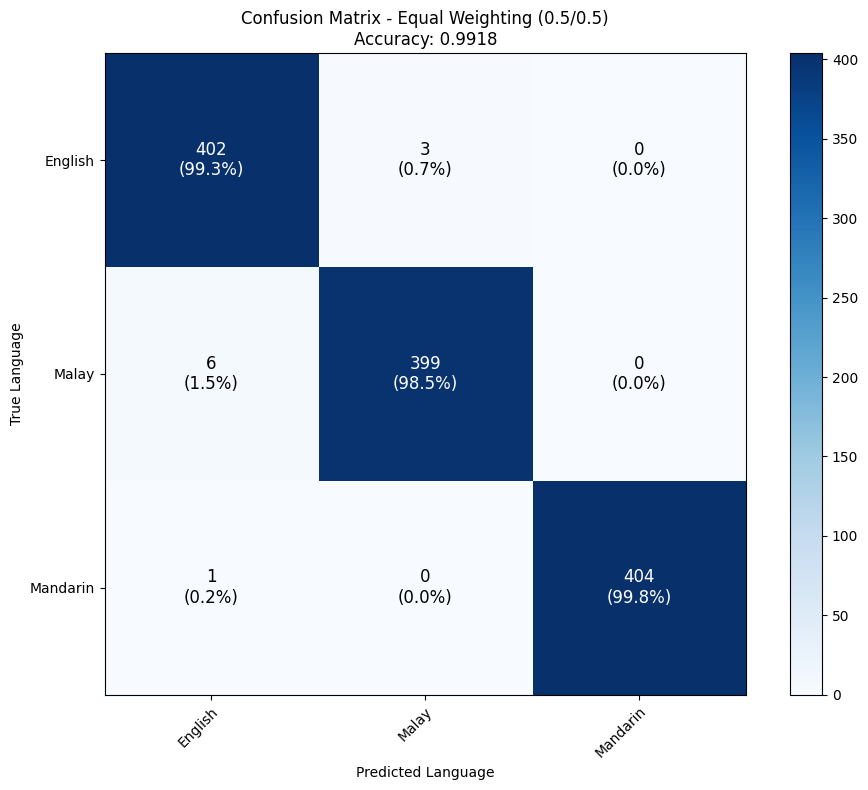

💾 Confusion matrix saved: wav2vec2_distilbert_confusion_matrix.png


In [32]:
# Confusion matrix visualization
cm = confusion_matrix(true_labels, best_preds)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)

ax.set(
    xticks=np.arange(len(LANGUAGE_NAMES)),
    yticks=np.arange(len(LANGUAGE_NAMES)),
    xticklabels=LANGUAGE_NAMES,
    yticklabels=LANGUAGE_NAMES,
    title=f'Confusion Matrix - {best_method}\nAccuracy: {best_accuracy:.4f}',
    ylabel='True Language',
    xlabel='Predicted Language'
)

plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

# Add annotations
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        percentage = 100.0 * cm[i, j] / cm[i].sum() if cm[i].sum() > 0 else 0
        text = f'{cm[i, j]}\n({percentage:.1f}%)'
        ax.text(j, i, text,
                ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black',
                fontsize=12)

plt.tight_layout()
plt.savefig('wav2vec2_distilbert_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('💾 Confusion matrix saved: wav2vec2_distilbert_confusion_matrix.png')

In [33]:
# Export comprehensive analysis results to JSON (for later graphing without reruns)
from datetime import datetime

# Build probability bundles for each method
method_probabilities = {
    'Audio Only (Wav2Vec2)': audio_probs,
    'Text Only (DistilBERT)': text_probs,
    'Equal Weighting (0.5/0.5)': fuse_equal(audio_probs, text_probs),
    'Accuracy-Weighted Fusion': fuse_accuracy_weighted(audio_probs, text_probs),
    'Confidence-Adaptive Fusion': fuse_confidence_adaptive(audio_probs, text_probs),
}

# Per-language accuracy per method
per_language_accuracy = {}
for method_name, probs in method_probabilities.items():
    preds = np.argmax(probs, axis=1)
    per_language_accuracy[method_name] = {}
    for lang_id, lang_name in enumerate(LANGUAGE_NAMES):
        mask = true_labels == lang_id
        if int(mask.sum()) > 0:
            per_language_accuracy[method_name][lang_name] = float(accuracy_score(true_labels[mask], preds[mask]))

# Confusion matrices for all methods
confusion_matrices = {}
for method_name, probs in method_probabilities.items():
    preds = np.argmax(probs, axis=1)
    confusion_matrices[method_name] = confusion_matrix(true_labels, preds).tolist()

# Classification reports for all methods
classification_reports = {}
for method_name, probs in method_probabilities.items():
    preds = np.argmax(probs, axis=1)
    classification_reports[method_name] = classification_report(
        true_labels, preds, target_names=LANGUAGE_NAMES, digits=4, zero_division=0, output_dict=True
    )

export_results = {
    'metadata': {
        'created_at': datetime.now().isoformat(timespec='seconds'),
        'methodology': 'Late Fusion: Wav2Vec2 + DistilBERT',
        'languages': LANGUAGE_NAMES,
        'language_ids': {k: int(v) for k, v in LANGUAGE_IDS.items()},
        'test_set_size': int(len(true_labels)),
        'notes': 'Comprehensive export for offline analysis and graph generation.'
    },
    'models': {
        'audio': 'facebook/wav2vec2-base (fine-tuned)',
        'text': 'distilbert-base-multilingual-cased (fine-tuned)'
    },
    'summary_results': {k: float(v) for k, v in results.items()},
    'best_method': {
        'name': best_method,
        'accuracy': float(best_accuracy)
    },
    'per_language_counts': {
        LANGUAGE_NAMES[i]: int(np.sum(true_labels == i))
        for i in range(len(LANGUAGE_NAMES))
    },
    'per_language_accuracy': per_language_accuracy,
    'confusion_matrices': confusion_matrices,
    'classification_reports': classification_reports,
    'labels_and_predictions': {
        'true_labels': true_labels.tolist(),
        'predictions': {
            method_name: np.argmax(probs, axis=1).tolist()
            for method_name, probs in method_probabilities.items()
        }
    },
    'probabilities': {
        method_name: probs.tolist()
        for method_name, probs in method_probabilities.items()
    }
}

# Keep backward-compatible single confusion matrix fields
export_results['confusion_matrix'] = confusion_matrices[best_method]

with open('wav2vec2_distilbert_full_analysis_results.json', 'w', encoding='utf-8') as f:
    json.dump(export_results, f, ensure_ascii=False, indent=2)

# Backward compatibility export used by older plotting cells
with open('wav2vec2_distilbert_fusion_results.json', 'w', encoding='utf-8') as f:
    json.dump({
        'methodology': export_results['metadata']['methodology'],
        'models': export_results['models'],
        'test_set_size': export_results['metadata']['test_set_size'],
        'results': export_results['summary_results'],
        'best_method': export_results['best_method'],
        'confusion_matrix': export_results['confusion_matrix'],
        'per_language_counts': export_results['per_language_counts']
    }, f, ensure_ascii=False, indent=2)

print('💾 Saved comprehensive export: wav2vec2_distilbert_full_analysis_results.json')
print('💾 Updated compatibility export: wav2vec2_distilbert_fusion_results.json')

💾 Saved comprehensive export: wav2vec2_distilbert_full_analysis_results.json
💾 Updated compatibility export: wav2vec2_distilbert_fusion_results.json


In [34]:
# Summary comparison table
print('\n' + '='*60)
print('SUMMARY COMPARISON')
print('='*60)

results_df = pd.DataFrame([
    {'Method': k, 'Test Accuracy': v}
    for k, v in results.items()
]).sort_values('Test Accuracy', ascending=False)

print(results_df.to_string(index=False))

improvement = (best_accuracy - max(results['Audio Only (Wav2Vec2)'], results['Text Only (DistilBERT)'])) * 100
print(f'\n✨ Improvement over best unimodal: {improvement:+.2f}%')
print('='*60)



SUMMARY COMPARISON
                    Method  Test Accuracy
 Equal Weighting (0.5/0.5)       0.991770
Confidence-Adaptive Fusion       0.990123
  Accuracy-Weighted Fusion       0.978601
    Text Only (DistilBERT)       0.972840
     Audio Only (Wav2Vec2)       0.941564

✨ Improvement over best unimodal: +1.89%


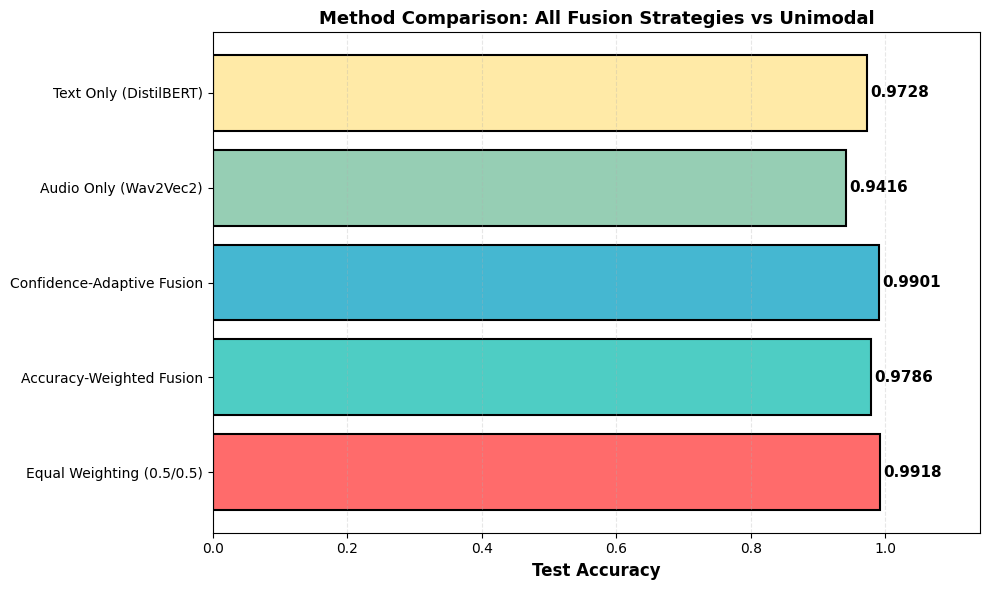

💾 Saved: 01_method_comparison.png


In [35]:

# Visualization 1: All Methods Accuracy Comparison
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 6))

methods = list(results.keys())
accuracies = list(results.values())
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']

bars = ax.barh(methods, accuracies, color=colors, edgecolor='black', linewidth=1.5)

# Add value labels
for i, (bar, acc) in enumerate(zip(bars, accuracies)):
    ax.text(acc + 0.005, bar.get_y() + bar.get_height()/2, 
            f'{acc:.4f}', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Test Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Method Comparison: All Fusion Strategies vs Unimodal', fontsize=13, fontweight='bold')
ax.set_xlim(0, max(accuracies) * 1.15)
ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('01_method_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('💾 Saved: 01_method_comparison.png')

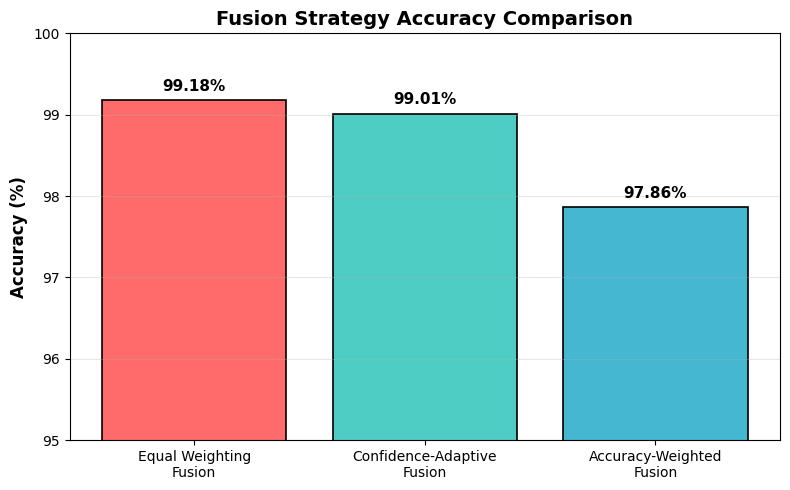

In [8]:
import json
import matplotlib.pyplot as plt

with open("wav2vec2_distilbert_fusion_results.json", "r", encoding="utf-8") as f:
    results = json.load(f)

fusion_keys = [
    "Equal Weighting (0.5/0.5)",
    "Confidence-Adaptive Fusion",
    "Accuracy-Weighted Fusion"
]

fusion_methods = [
    "Equal Weighting\nFusion",
    "Confidence-Adaptive\nFusion",
    "Accuracy-Weighted\nFusion"
]

accuracies = [results["results"][key] * 100 for key in fusion_keys]

colors = ["#FF6B6B", "#4ECDC4", "#45B7D1"]

plt.figure(figsize=(8, 5))
bars = plt.bar(fusion_methods, accuracies, color=colors, edgecolor="black", linewidth=1.2)

plt.ylabel("Accuracy (%)", fontsize=12, fontweight="bold")
plt.title("Fusion Strategy Accuracy Comparison", fontsize=14, fontweight="bold")
plt.ylim(95, 100)
plt.grid(axis="y", alpha=0.3)

for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.08,
        f"{acc:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.savefig("Figure_5_4_Fusion_Strategy_Accuracy_Comparison.png", dpi=300, bbox_inches="tight")
plt.show()

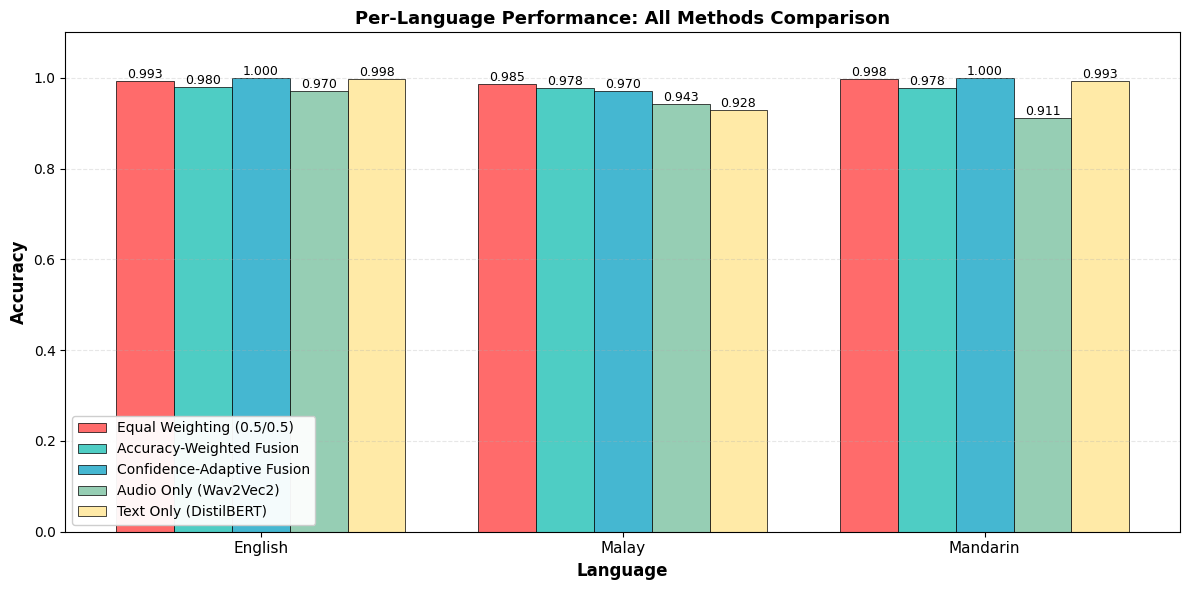

💾 Saved: 02_per_language_comparison.png


In [36]:

# Visualization 2: Per-Language Accuracy - All Methods
fig, ax = plt.subplots(figsize=(12, 6))

# Get per-language accuracies for each method
method_names = list(results.keys())
lang_per_method = {method: [] for method in method_names}

for method_name in method_names:
    preds = all_predictions[method_name]
    for lang_id, lang_name in enumerate(LANGUAGE_NAMES):
        mask = true_labels == lang_id
        if mask.sum() > 0:
            lang_acc = accuracy_score(true_labels[mask], preds[mask])
            lang_per_method[method_name].append(lang_acc)

# Plot grouped bars
x = np.arange(len(LANGUAGE_NAMES))
width = 0.16

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']

for idx, method in enumerate(method_names):
    offset = (idx - 2) * width
    bars = ax.bar(x + offset, lang_per_method[method], width, 
                  label=method, color=colors[idx], edgecolor='black', linewidth=0.5)
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Language', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Per-Language Performance: All Methods Comparison', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(LANGUAGE_NAMES, fontsize=11)
ax.set_ylim(0, 1.1)
ax.legend(loc='lower left', fontsize=10, framealpha=0.95)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('02_per_language_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('💾 Saved: 02_per_language_comparison.png')

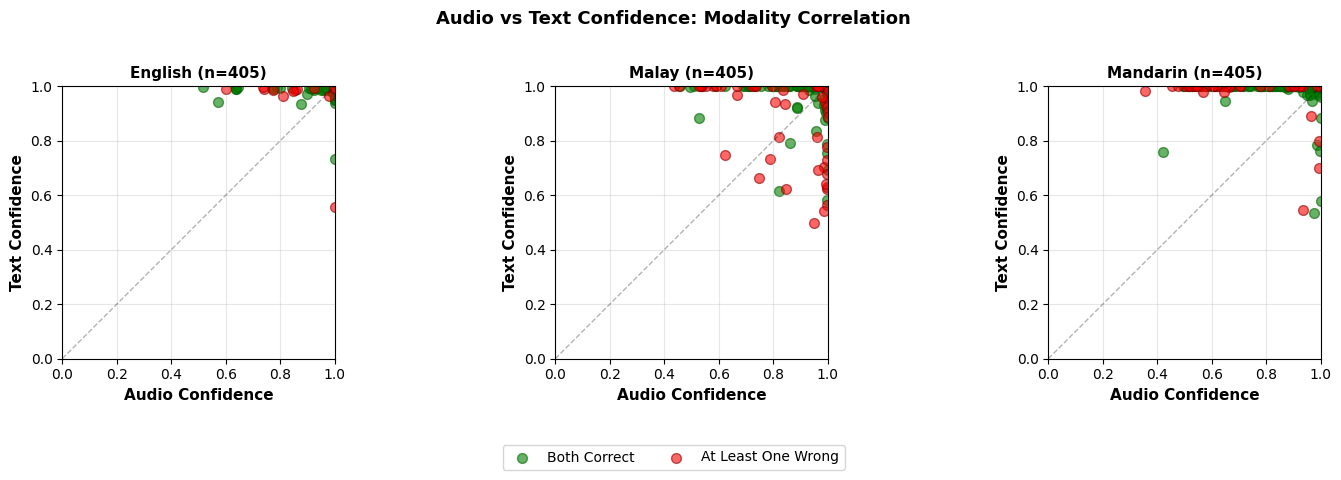

💾 Saved: 03_confidence_correlation.png


In [37]:

# Visualization 3: Audio vs Text Confidence Scatter Plot
fig, axes = plt.subplots(1, len(LANGUAGE_NAMES), figsize=(15, 4))

audio_preds = all_predictions['Audio Only (Wav2Vec2)']
text_preds = all_predictions['Text Only (DistilBERT)']
audio_probs = audio_pred_probs
text_probs = text_pred_probs

for lang_id, lang_name in enumerate(LANGUAGE_NAMES):
    ax = axes[lang_id]
    
    mask = true_labels == lang_id
    
    # Get max confidence for each sample
    audio_conf = audio_probs[mask].max(axis=1)
    text_conf = text_probs[mask].max(axis=1)
    
    # Check if predictions are correct
    is_correct = (audio_preds[mask] == true_labels[mask]) & (text_preds[mask] == true_labels[mask])
    
    # Plot
    scatter = ax.scatter(audio_conf[is_correct], text_conf[is_correct], 
                        alpha=0.6, s=50, c='green', label='Both Correct', edgecolors='darkgreen')
    scatter = ax.scatter(audio_conf[~is_correct], text_conf[~is_correct], 
                        alpha=0.6, s=50, c='red', label='At Least One Wrong', edgecolors='darkred')
    
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=1)
    ax.set_xlabel('Audio Confidence', fontsize=11, fontweight='bold')
    ax.set_ylabel('Text Confidence', fontsize=11, fontweight='bold')
    ax.set_title(f'{lang_name} (n={mask.sum()})', fontsize=11, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    ax.set_aspect('equal')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2, fontsize=10)

plt.suptitle('Audio vs Text Confidence: Modality Correlation', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('03_confidence_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('💾 Saved: 03_confidence_correlation.png')

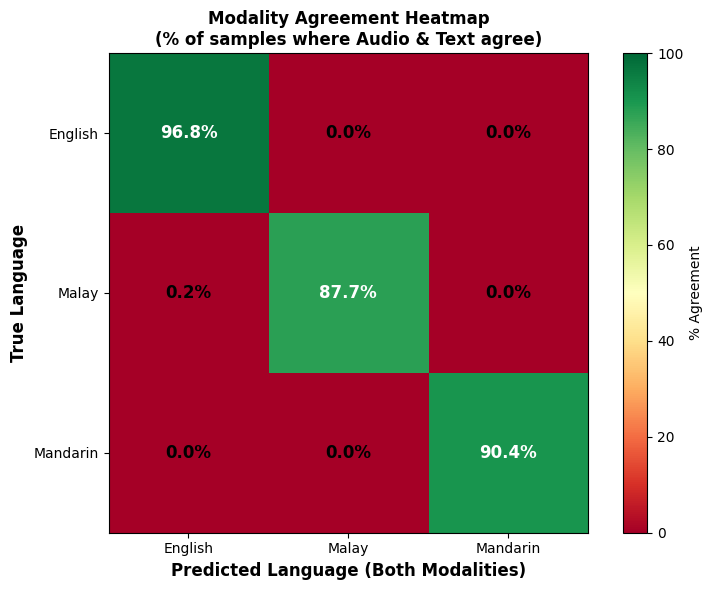

💾 Saved: 04_modality_agreement.png


In [38]:

# Visualization 4: Modality Agreement Heatmap
fig, ax = plt.subplots(figsize=(8, 6))

audio_preds = all_predictions['Audio Only (Wav2Vec2)']
text_preds = all_predictions['Text Only (DistilBERT)']

# Create agreement matrix
agreement_matrix = np.zeros((len(LANGUAGE_NAMES), len(LANGUAGE_NAMES)))

for true_lang in range(len(LANGUAGE_NAMES)):
    mask = true_labels == true_lang
    true_samples = np.sum(mask)
    
    for pred_combo in range(len(LANGUAGE_NAMES)):
        # Count samples where audio predicts pred_combo
        both_same = ((audio_preds == pred_combo) & (text_preds == pred_combo) & mask).sum()
        agreement_matrix[true_lang, pred_combo] = 100.0 * both_same / true_samples if true_samples > 0 else 0

im = ax.imshow(agreement_matrix, cmap='RdYlGn', vmin=0, vmax=100)
ax.figure.colorbar(im, ax=ax, label='% Agreement')

ax.set_xticks(np.arange(len(LANGUAGE_NAMES)))
ax.set_yticks(np.arange(len(LANGUAGE_NAMES)))
ax.set_xticklabels(LANGUAGE_NAMES)
ax.set_yticklabels(LANGUAGE_NAMES)
ax.set_xlabel('Predicted Language (Both Modalities)', fontsize=12, fontweight='bold')
ax.set_ylabel('True Language', fontsize=12, fontweight='bold')
ax.set_title('Modality Agreement Heatmap\n(% of samples where Audio & Text agree)', 
             fontsize=12, fontweight='bold')

# Add annotations
for i in range(len(LANGUAGE_NAMES)):
    for j in range(len(LANGUAGE_NAMES)):
        text = ax.text(j, i, f'{agreement_matrix[i, j]:.1f}%',
                      ha='center', va='center', color='black' if agreement_matrix[i, j] < 50 else 'white',
                      fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('04_modality_agreement.png', dpi=150, bbox_inches='tight')
plt.show()

print('💾 Saved: 04_modality_agreement.png')

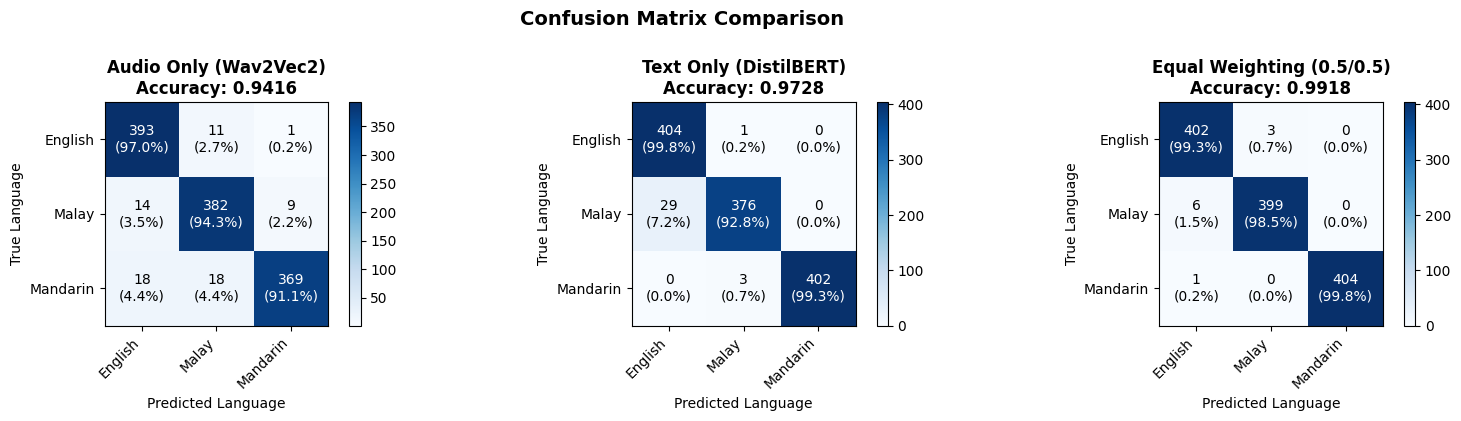

💾 Saved: 05_confusion_matrices_comparison.png


In [40]:

# Visualization 5: Confusion Matrices - Audio vs Text vs Best Fusion
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

methods_to_plot = [
    ('Audio Only (Wav2Vec2)', axes[0]),
    ('Text Only (DistilBERT)', axes[1]),
    (best_method, axes[2])
]

for method_name, ax in methods_to_plot:
    preds = all_predictions[method_name]
    cm = confusion_matrix(true_labels, preds)
    
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)
    
    ax.set(
        xticks=np.arange(len(LANGUAGE_NAMES)),
        yticks=np.arange(len(LANGUAGE_NAMES)),
        xticklabels=LANGUAGE_NAMES,
        yticklabels=LANGUAGE_NAMES,
        ylabel='True Language',
        xlabel='Predicted Language'
    )
    
    # Compute accuracy for this method
    acc = accuracy_score(true_labels, preds)
    ax.set_title(f'{method_name}\nAccuracy: {acc:.4f}', fontweight='bold')
    
    # Add annotations
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            percentage = 100.0 * cm[i, j] / cm[i].sum() if cm[i].sum() > 0 else 0
            text = f'{cm[i, j]}\n({percentage:.1f}%)'
            ax.text(j, i, text,
                    ha='center', va='center',
                    color='white' if cm[i, j] > thresh else 'black',
                    fontsize=10)
    
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.suptitle('Confusion Matrix Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('05_confusion_matrices_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('💾 Saved: 05_confusion_matrices_comparison.png')

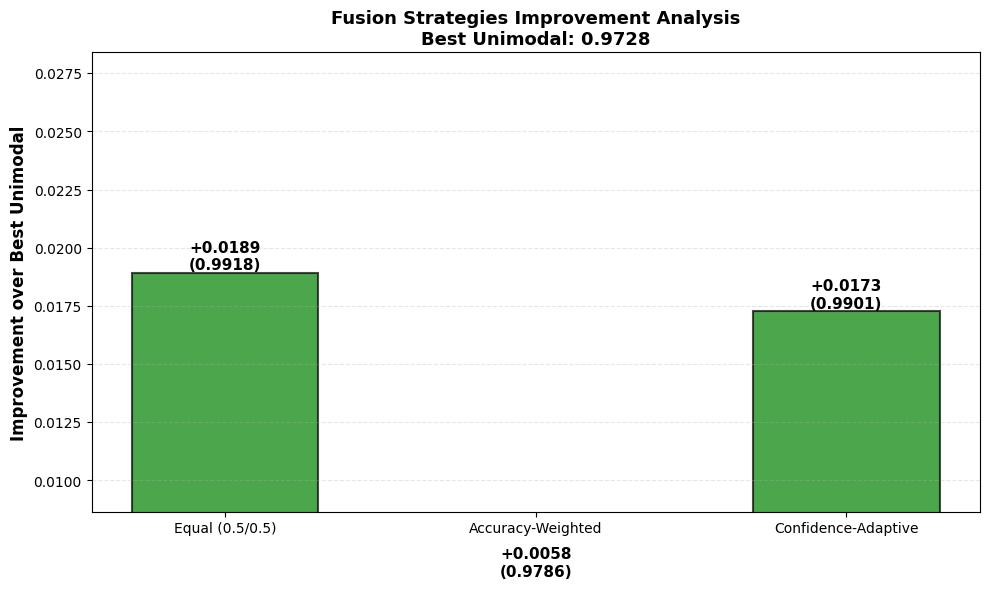

💾 Saved: 06_fusion_improvement.png

Best Unimodal: 0.9728 (Text)
Fusion Improvements:
  Equal (0.5/0.5): +0.0189 (0.9918)
  Accuracy-Weighted: +0.0058 (0.9786)
  Confidence-Adaptive: +0.0173 (0.9901)


In [41]:

# Visualization 6: Fusion Improvement Over Unimodal
fig, ax = plt.subplots(figsize=(10, 6))

audio_acc = results['Audio Only (Wav2Vec2)']
text_acc = results['Text Only (DistilBERT)']
best_unimodal_acc = max(audio_acc, text_acc)

fusion_methods = ['Equal (0.5/0.5)', 'Accuracy-Weighted', 'Confidence-Adaptive']
fusion_accs = [results['Equal Weighting (0.5/0.5)'], 
               results['Accuracy-Weighted Fusion'],
               results['Confidence-Adaptive Fusion']]

improvement = [acc - best_unimodal_acc for acc in fusion_accs]
colors_imp = ['green' if imp > 0 else 'red' for imp in improvement]

bars = ax.bar(fusion_methods, improvement, color=colors_imp, edgecolor='black', 
              linewidth=1.5, alpha=0.7, width=0.6)

# Add value labels
for bar, imp, acc in zip(bars, improvement, fusion_accs):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{imp:+.4f}\n({acc:.4f})', ha='center', 
            va='bottom' if height > 0 else 'top', fontsize=11, fontweight='bold')

ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.set_ylabel('Improvement over Best Unimodal', fontsize=12, fontweight='bold')
ax.set_title(f'Fusion Strategies Improvement Analysis\nBest Unimodal: {best_unimodal_acc:.4f}', 
             fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(min(improvement) * 1.5, max(improvement) * 1.5)

plt.tight_layout()
plt.savefig('06_fusion_improvement.png', dpi=150, bbox_inches='tight')
plt.show()

print('💾 Saved: 06_fusion_improvement.png')
print(f'\nBest Unimodal: {best_unimodal_acc:.4f} ({"Audio" if audio_acc > text_acc else "Text"})')
print(f'Fusion Improvements:')
for method, imp, acc in zip(fusion_methods, improvement, fusion_accs):
    print(f'  {method}: {imp:+.4f} ({acc:.4f})')

In [42]:

# Detailed Analysis: Where Fusion Helps Most
print('\n' + '='*70)
print('DETAILED ANALYSIS: WHERE FUSION HELPS MOST')
print('='*70)

audio_preds = all_predictions['Audio Only (Wav2Vec2)']
text_preds = all_predictions['Text Only (DistilBERT)']
best_preds = all_predictions[best_method]

# Categorize samples
both_right = (audio_preds == true_labels) & (text_preds == true_labels)
both_wrong = (audio_preds != true_labels) & (text_preds != true_labels)
audio_right_text_wrong = (audio_preds == true_labels) & (text_preds != true_labels)
audio_wrong_text_right = (audio_preds != true_labels) & (text_preds == true_labels)
fusion_fixed = (best_preds == true_labels) & ((audio_preds != true_labels) | (text_preds != true_labels))

print('\nSample Categorization:')
print(f'  Both Modalities Correct: {both_right.sum():4d} ({100*both_right.sum()/len(true_labels):5.2f}%)')
print(f'  Both Modalities Wrong:   {both_wrong.sum():4d} ({100*both_wrong.sum()/len(true_labels):5.2f}%)')
print(f'  Only Audio Correct:      {audio_right_text_wrong.sum():4d} ({100*audio_right_text_wrong.sum()/len(true_labels):5.2f}%)')
print(f'  Only Text Correct:       {audio_wrong_text_right.sum():4d} ({100*audio_wrong_text_right.sum()/len(true_labels):5.2f}%)')
print(f'  Fusion Fixed Errors:     {fusion_fixed.sum():4d} ({100*fusion_fixed.sum()/len(true_labels):5.2f}%)')

print('\nPer-Language Analysis:')
for lang_id, lang_name in enumerate(LANGUAGE_NAMES):
    mask = true_labels == lang_id
    
    audio_acc = accuracy_score(true_labels[mask], audio_preds[mask])
    text_acc = accuracy_score(true_labels[mask], text_preds[mask])
    fusion_acc = accuracy_score(true_labels[mask], best_preds[mask])
    
    print(f'\n  {lang_name}:')
    print(f'    Audio Acc:    {audio_acc:.4f}')
    print(f'    Text Acc:     {text_acc:.4f}')
    print(f'    Fusion Acc:   {fusion_acc:.4f}')
    print(f'    Fusion Gain:  {fusion_acc - max(audio_acc, text_acc):+.4f}')
    
    # Count errors fixed by fusion
    mask_fusion = mask & ((audio_preds != true_labels) | (text_preds != true_labels))
    if mask_fusion.sum() > 0:
        fixed = ((best_preds[mask_fusion] == true_labels[mask_fusion])).sum()
        print(f'    Errors Fixed by Fusion: {fixed}/{mask_fusion.sum()}')

print('\n' + '='*70)


DETAILED ANALYSIS: WHERE FUSION HELPS MOST

Sample Categorization:
  Both Modalities Correct: 1113 (91.60%)
  Both Modalities Wrong:      2 ( 0.16%)
  Only Audio Correct:        31 ( 2.55%)
  Only Text Correct:         69 ( 5.68%)
  Fusion Fixed Errors:       92 ( 7.57%)

Per-Language Analysis:

  English:
    Audio Acc:    0.9704
    Text Acc:     0.9975
    Fusion Acc:   0.9926
    Fusion Gain:  -0.0049
    Errors Fixed by Fusion: 10/13

  Malay:
    Audio Acc:    0.9432
    Text Acc:     0.9284
    Fusion Acc:   0.9852
    Fusion Gain:  +0.0420
    Errors Fixed by Fusion: 44/50

  Mandarin:
    Audio Acc:    0.9111
    Text Acc:     0.9926
    Fusion Acc:   0.9975
    Fusion Gain:  +0.0049
    Errors Fixed by Fusion: 38/39



In [1]:
# Load OCR extraction state from saved file (skip rerunning OCR)
import json
import os

OCR_EXTRACT_FILE = 'ocr_extracted_texts.json'

if not os.path.exists(OCR_EXTRACT_FILE):
    raise FileNotFoundError(f"{OCR_EXTRACT_FILE} not found. Run OCR extraction cells once to create it.")

with open(OCR_EXTRACT_FILE, 'r', encoding='utf-8') as f:
    saved_ocr = json.load(f)

# Restore main variables used by downstream cells
text_samples_full = saved_ocr.get('text_samples_full', {})
text_samples_full_easy = saved_ocr.get('text_samples_full_easy', {})
extraction_stats_easy = saved_ocr.get('extraction_stats_easy', {})

# Optional metadata restore (only if present)
if 'languages' in saved_ocr:
    LANGUAGES = saved_ocr['languages']
if 'language_names' in saved_ocr:
    LANGUAGE_NAMES = saved_ocr['language_names']

print(f"Loaded OCR state from: {OCR_EXTRACT_FILE}")
print('-' * 60)

for lc in LANGUAGES:
    n_main = len(text_samples_full.get(lc, []))
    n_easy = len(text_samples_full_easy.get(lc, []))
    stats = extraction_stats_easy.get(lc, {})
    success = stats.get('success', 0)
    empty = stats.get('empty', 0)
    failed = stats.get('failed', 0)
    print(f"{lc.upper():>3} | main={n_main:5d} | easy={n_easy:5d} | success={success:5d}, empty={empty:5d}, failed={failed:5d}")

print('-' * 60)
print('OCR variables restored. You can continue from test split / fusion cells directly.')

Loaded OCR state from: ocr_extracted_texts.json
------------------------------------------------------------
 EN | main= 5000 | easy= 4993 | success= 4993, empty=    7, failed=    0
 MS | main= 5000 | easy= 5000 | success= 5000, empty=    0, failed=    0
 ZH | main= 5000 | easy= 5000 | success= 5000, empty=    0, failed=    0
------------------------------------------------------------
OCR variables restored. You can continue from test split / fusion cells directly.


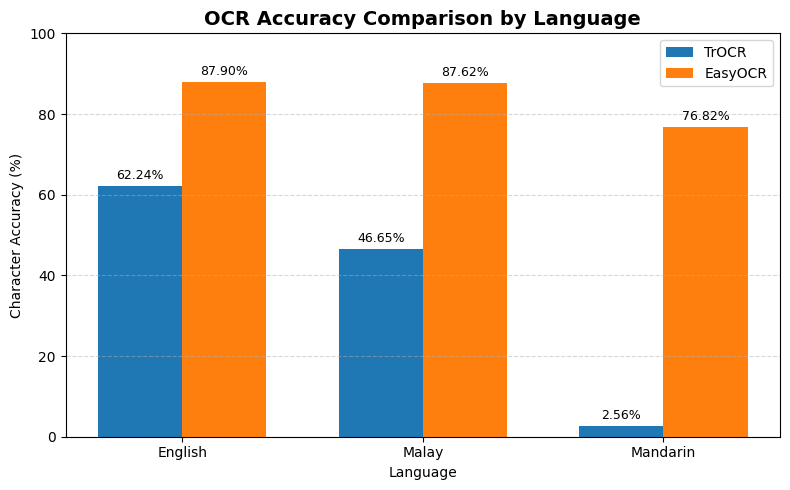

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Data
languages = ["English", "Malay", "Mandarin"]
trocr = [62.24, 46.65, 2.56]
easyocr = [87.90, 87.62, 76.82]

x = np.arange(len(languages))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(x - width/2, trocr, width, label="TrOCR")
bars2 = ax.bar(x + width/2, easyocr, width, label="EasyOCR")

# Labels
ax.set_title("OCR Accuracy Comparison by Language",
             fontsize=14,
             fontweight="bold")
ax.set_xlabel("Language")
ax.set_ylabel("Character Accuracy (%)")
ax.set_xticks(x)
ax.set_xticklabels(languages)
ax.set_ylim(0, 100)

# Grid
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Legend
ax.legend()

# Value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 1,
            f"{height:.2f}%",
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()

# Save figure
output_dir = Path("figures")
output_dir.mkdir(exist_ok=True)


plt.show()



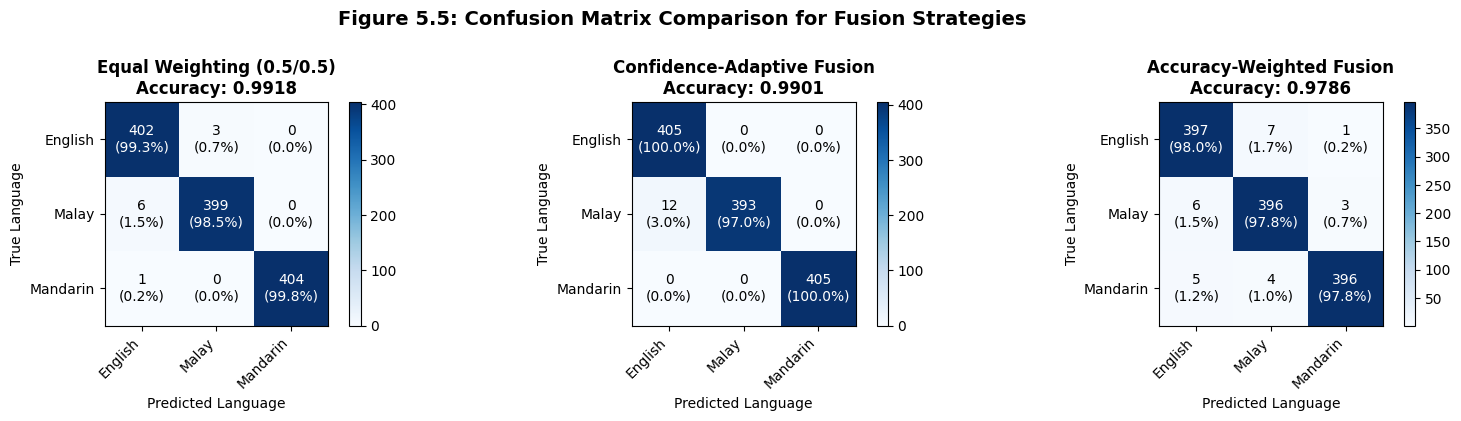

In [7]:
import json
import numpy as np
import matplotlib.pyplot as plt

LANGUAGE_NAMES = ["English", "Malay", "Mandarin"]

with open("wav2vec2_distilbert_full_analysis_results.json", "r", encoding="utf-8") as f:
    results = json.load(f)

fusion_methods = [
    "Equal Weighting (0.5/0.5)",
    "Confidence-Adaptive Fusion",
    "Accuracy-Weighted Fusion"
]

confusion_matrices = results["confusion_matrices"]
summary_results = results["summary_results"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for method_name, ax in zip(fusion_methods, axes):
    cm = np.array(confusion_matrices[method_name])
    acc = summary_results[method_name]

    im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(LANGUAGE_NAMES)),
        yticks=np.arange(len(LANGUAGE_NAMES)),
        xticklabels=LANGUAGE_NAMES,
        yticklabels=LANGUAGE_NAMES,
        ylabel="True Language",
        xlabel="Predicted Language"
    )

    ax.set_title(
        f"{method_name}\nAccuracy: {acc:.4f}",
        fontweight="bold"
    )

    thresh = cm.max() / 2.0

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            percentage = 100.0 * cm[i, j] / cm[i].sum() if cm[i].sum() > 0 else 0
            text = f"{cm[i, j]}\n({percentage:.1f}%)"

            ax.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=10
            )

    plt.setp(
        ax.get_xticklabels(),
        rotation=45,
        ha="right"
    )

plt.suptitle(
    "Figure 5.5: Confusion Matrix Comparison for Fusion Strategies",
    fontsize=14,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()


plt.show()


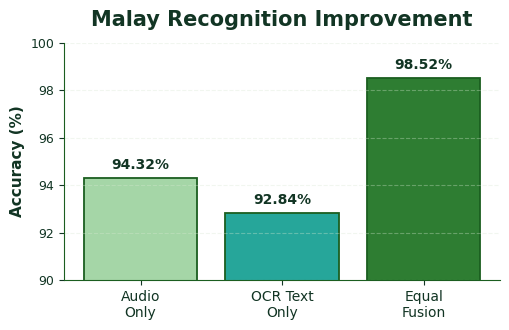

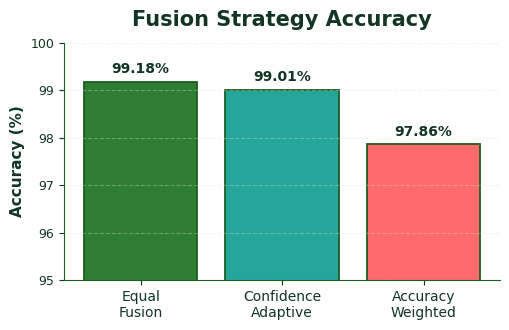

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Poster-friendly colors
GREEN = "#2E7D32"      # main poster green
DARK_GREEN = "#1B5E20"
LIGHT_GREEN = "#A5D6A7"
TEAL = "#26A69A"
CORAL = "#FF6B6B"
BLUE_TEAL = "#4DB6AC"
GRID = "#D7E8D2"
TEXT = "#123524"

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"


# =========================
# Chart 1: Malay Recognition Improvement
# =========================

methods = ["Audio\nOnly", "OCR Text\nOnly", "Equal\nFusion"]
malay_acc = [94.32, 92.84, 98.52]
colors = [LIGHT_GREEN, TEAL, GREEN]

fig, ax = plt.subplots(figsize=(5.2, 3.4))
fig.patch.set_alpha(0)
ax.set_facecolor("none")

bars = ax.bar(methods, malay_acc, color=colors, edgecolor=DARK_GREEN, linewidth=1.3)

ax.set_title("Malay Recognition Improvement", fontsize=15, color=TEXT, pad=12)
ax.set_ylabel("Accuracy (%)", fontsize=11, color=TEXT)
ax.set_ylim(90, 100)
ax.grid(axis="y", linestyle="--", alpha=0.35, color=GRID)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(DARK_GREEN)
ax.spines["bottom"].set_color(DARK_GREEN)
ax.tick_params(axis="x", labelsize=10, colors=TEXT)
ax.tick_params(axis="y", labelsize=9, colors=TEXT)

for bar, value in zip(bars, malay_acc):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.25,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=TEXT
    )



plt.tight_layout()
plt.savefig(
    "poster_malay_recognition_improvement.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)
plt.show()


# =========================
# Chart 2: Fusion Strategy Accuracy
# =========================

fusion_methods = [
    "Equal\nFusion",
    "Confidence\nAdaptive",
    "Accuracy\nWeighted"
]
fusion_acc = [99.18, 99.01, 97.86]
colors = [GREEN, TEAL, CORAL]

fig, ax = plt.subplots(figsize=(5.2, 3.4))
fig.patch.set_alpha(0)
ax.set_facecolor("none")

bars = ax.bar(fusion_methods, fusion_acc, color=colors, edgecolor=DARK_GREEN, linewidth=1.3)

ax.set_title("Fusion Strategy Accuracy", fontsize=15, color=TEXT, pad=12)
ax.set_ylabel("Accuracy (%)", fontsize=11, color=TEXT)
ax.set_ylim(95, 100)
ax.grid(axis="y", linestyle="--", alpha=0.35, color=GRID)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(DARK_GREEN)
ax.spines["bottom"].set_color(DARK_GREEN)
ax.tick_params(axis="x", labelsize=10, colors=TEXT)
ax.tick_params(axis="y", labelsize=9, colors=TEXT)

for bar, value in zip(bars, fusion_acc):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.12,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=TEXT
    )



plt.tight_layout()
plt.savefig(
    "poster_fusion_strategy_accuracy.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)
plt.show()